# Analyse Exploratoire

### Import des modules

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Analyse Exploratoire

1) Chargement et présentation des données

In [44]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [45]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [46]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

2) Description des variables

a) Description globale des variables (supposé)

On liste ici les différentes variables et leur signification (supposé) :

1. Identifiants et informations
- #1 - OSEBuildingID : Un identifiant unique attribué à chaque propriété couverte par l'ordonnance de Seattle.
- #2 - DataYear : Année civile de chaque enregistrement de données.
- #3 - BuildingType : Classification des types de bâtiments de haut niveau de la ville de Seattle (Non-résidentiel, Campus, familiale, etc.).
- #5 -  PropertyName : Nom du batiment
- #15 - YearBuilt : L'année de construction. Plus un bâtiment est vieux, plus son isolation est potentiellement datée.


2. Localisation (L'influence géographique)
- #6 - Address : Adresse du bien à Seattle.
- #7 - City : Ville (Seattle partout).
- #8 - State : Etat (Washington partout).
- #9 - Zip Code : Code postal (commence tous par 98).
- #10 - TaxParcelIdentificationNumber : Numéro d'identification de parcelle (PIN) du comté de King.
- #11 - CouncilDistrictCode : Code du district municipal (utile pour des politiques publiques).
- #12 - Neighborhood : Le quartier de Seattle.
- #13/14 - Latitude / Longitude : Coordonnées précises - permettent de voir s'il y a des "clusters" (zones) de forte consommation, en fonction d'une exposition potentielles à des phénomènes climatiques.


3. Informations Structurelles (Les caractéristiques physiques)
- #16 - NumberofBuildings : Le nombre de bâtiments sur la propriété (certains complexes ont plusieurs batiment).
- #17 - NumberofFloors : Le nombre d'étages 'habitales' (à partir du nouveau du sol ou au dessus).
- #18 - PropertyGFATotal : La surface totale (GFA - Gross Floor Area) brute et batiment et du stationnement en pieds carrés.
- #19 - PropertyGFAParking : Surface totale en pieds carrés de tous types de stationnement (entièrement fermé, partiellement fermé et ouvert), mais exclut les surface de batiment (plancher) non dédié au stationnement.
- #20 - PropertyGFABuilding(s) : Surface totale de plancher (en pieds carrés) entre les murs extérieurs d'un bâtiment. Elle comprend toutes les surfaces intérieures (locaux locatifs, parties communes, cages d'escalier, sous-sols, espaces de stockage, etc.), mais exclut le stationnement.

4. Typologie et Usage (L'activité humaine - les usages du batiment)
- #4 - PrimaryPropertyType : L'usage principal déclaré (Hôtel, Bureau, Entrepôt) pour le batiment. Il s'agit avant tout d'une étiquette et d'une classification administrative pour les registres de la ville. Ce n'est pas nécessairement vraie dans la réalité de l'utilisation en terme de surface. C'est ce que nous verrons plus loin dans l'étude...
- #21 - ListOfAllPropertyUseTypes : Liste des tous les usages réels occupé par le batiment (sous forme de lite séparé par une virgule).
- #22 - LargestPropertyUseType : Le type d'utilisation du bien le plus important en fonction de la surface brute du bâtiment. Autrement dit, L'usage réel qui occupe la plus grande surface.
- #23 - LargestPropertyUseTypeGFA (sf) : La surface exacte de cet usage principal (LargestPropertyUseType).
- #24 - SecondLargestPropertyUseType :  Le deuxième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment. Utile pour les bâtiments mixtes (ex: un immeuble de bureaux avec un restaurant au rez-de-chaussée).
- #25 - SecondLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce second usage.
- #26 - ThirdLargestPropertyUseType :  Le troisième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment.
- #27 - ThirdLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce troisème usage.

5. Indicateurs de consommations énergetiques (Cibles - targets potentielles)

    a. Indicateurs spécifiques (par type d'energie).

- #36 - SteamUse(kBtu) : La quantité annuelle de vapeur de réseau consommée par la propriété sur place, mesurée en milliers d'unités thermiques britanniques (kBtu).

- #37 - Electricity(kWh) : 	La quantité annuelle d'électricité consommée par la propriété sur place, y compris l'électricité achetée sur le réseau et produite par les systèmes renouvelables sur place, mesurée en kWh.
- #38 - Electricity(kBtu) : Cette même quantité, exprimé en kBtu.

- #39 - NaturalGas(therms) : La quantité annuelle de gaz naturel fourni par le service public et consommée par la propriété, mesurée en thermies.
- #40 - NaturalGas(kBtu) : Cette même quantité, exprimé en kBtu.

    b. Indicateurs globaux (tout type d'energie confondues).
   
- #34 - SiteEnergyUse(kBtu) : La quantité annuelle d'énergie consommée réellement par la propriété, toutes sources d'énergie confondues. Cible principale de cette étude. Elle est mesurée en milliers (kilos) de BTU British thermal unit. Ce chiffre correspond exactement à la somme des 3 consommations réelles énoncées précedemment : SteamUse(kBtu) + Electricity(kBtu) + NaturalGas(kBtu).
- #35 - SiteEnergyUseWN(kBtu) : Idem, mais Weather Normalized. Elle simule ce qu'aurait été la consommation si l'année avait eu des températures standards : "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans".

- #30 - SiteEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) du site. L'intensité énergétique du site (IES) correspond à la consommation énergétique totale du site d'un bâtiment divisée par sa surface brute. Cela permet de comparer un petit et un grand bâtiment sur une base égale. Elle est mesurée en kBtu par pied carrés (sf - square feet). 
- #31 - SiteEUIWN(kBtu/sf) : Idem, mais Weather Normalized : "L'énergie du site WN correspond à la consommation énergétique du site lors des 30 dernières années, dans des conditions météorologiques moyennes". Elle est mesurée en kBtu par pied carrés (sf - square feet).

- #32 - SourceEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) de la source. L'intensité d'usage énergétique de la source (IES) correspond à la consommation énergétique d'un bâtiment à la source, divisée par sa surface brute. Contrairement au "Site", elle prend en compte l'énergie perdue lors de la production et du transport (très utile pour l'impact écologique global).
- #33 - SourceEUIWN(kBtu/sf) : Idem, mais Weather Normalized. "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans'.

6. Indicateurs de Performance énergetiques
- #28 - YearsENERGYSTARCertified : Année d'attribution de l'ENERGYSTARScore (ci-dessous)
- #29 - ENERGYSTARScore :	L'EPA attribue une note de 1 à 100 qui évalue la performance énergétique globale d'un bâtiment, en se basant sur des données nationales afin de neutraliser les différences liées au climat, à l'usage du bâtiment et à son exploitation (100 est le meilleur).Un score de 50 signifie que le bâtiment est dans la moyenne nationale pour son type.

7. Emissions de Gaz à Effet de Serre
- #45 - TotalGHGEmissions : Les émissions totales de gaz à effet de serre (en tonnes métriques d'équivalent CO2). Cela inclut le dioxyde de carbone, le méthane et l'oxyde nitreux, rejetées dans l'atmosphère du fait de la consommation d'énergie du bâtiment.
- #46 - GHGEmissionsIntensity : Les émissions totales (TotalGHGEmissions) rapportées à la surface brute du batiment (en pieds carrés).

8. Autre
- #41 - DefaultData : Indicateur (vrai/faux) précisant si des données par défaut ont été utilisées à la place de mesures réelles.
- #42 - Comments : Commentaires libres ajoutés lors du relevé.
- #43 - ComplianceStatus : Statut de conformité du bâtiment vis-à-vis de la loi sur le benchmarking  (Compliant/Nom-Compliant/Error - Correct Default Data/Missing Data). Peut-être utilse pour la prédiction de la consommation d'energie (dans le but de discrediter certains batiments). 
- #44 - Outlier : Indicateur signalant si le bâtiment a été identifié comme une valeur aberrante (par la ville).

b) Statistiques sur les variables quantitatives

On donnera les éléments principales de ces variables grâce à la fonction describe(). Cette fonction donne les informations suivantes : 
- nombre d'occurences (ou valeurs présentes), sur 3376 lignes au total.
- la moyenne
- l'écart type (la moyenne des écarts à la moyenne)
- la valeur minimum
- les écarts interquartiles (quel est la valeur pour laquelle 25% des "effectifs" ont en dessous de cette valeur, 50% des effectifs, etc, etc).
- la valeur maximum

In [47]:
# ============================================================
# DESCRIPTION DES VARIABLES QUANTITATIVES
# ============================================================

cols_quantitatives = building_consumption.select_dtypes(include=['number']).columns.tolist()
cols_quantitatives.remove("ZipCode")
cols_quantitatives.remove("CouncilDistrictCode")
cols_quantitatives.remove("OSEBuildingID")
cols_quantitatives.remove("Comments")
print(f"{len(cols_quantitatives)} colonnes numériques\n")

building_consumption[cols_quantitatives].describe().T.round(2)

26 colonnes numériques



,count,mean,std,min,25%,50%,75%,max
DataYear,3376.0,2016.00,0.00,2016.00,2016.00,2016.00,2016.00,2.016000e+03
Latitude,3376.0,47.62,0.05,47.50,47.60,47.62,47.66,4.773000e+01
Longitude,3376.0,-122.33,0.03,-122.41,-122.35,-122.33,-122.32,-1.222200e+02
YearBuilt,3376.0,1968.57,33.09,1900.00,1948.00,1975.00,1997.00,2.015000e+03
NumberofBuildings,3368.0,1.11,2.11,0.00,1.00,1.00,1.00,1.110000e+02
NumberofFloors,3376.0,4.71,5.49,0.00,2.00,4.00,5.00,9.900000e+01
PropertyGFATotal,3376.0,94833.54,218837.61,11285.00,28487.00,44175.00,90992.00,9.320156e+06
PropertyGFAParking,3376.0,8001.53,32326.72,0.00,0.00,0.00,0.00,5.126080e+05
PropertyGFABuilding(s),3376.0,86832.01,207939.81,3636.00,27756.00,43216.00,84276.25,9.320156e+06
LargestPropertyUseTypeGFA,3356.0,79177.64,201703.41,5656.00,25094.75,39894.00,76200.25,9.320156e+06


c) Statistiques des variables qualitatives

On décrit chaque variables en lisant ses modalités et le nombre d'occurences de chacune de ses modalités

In [48]:
# ============================================================
# DESCRIPTION DES VARIABLES QUALITATIVES (CATÉGORIELLES)
# ============================================================

cols_qualitatives = building_consumption.select_dtypes(include=['object', 'str']).columns.tolist()
cols_qualitatives.append("ZipCode")
cols_qualitatives.append("CouncilDistrictCode")
cols_qualitatives.append("OSEBuildingID")
cols_qualitatives.append("Comments")
cols_qualitatives.append("DefaultData")
print(f"{len(cols_qualitatives)} colonnes catégorielles\n")

SEUIL_PCT = 5  # n'affiche que les modalités >= 5% de l'effectif

for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    counts = building_consumption[col].value_counts()
    top = counts[counts / len(building_consumption) * 100 >= SEUIL_PCT]
    
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top.items():
        pct = count / len(building_consumption) * 100
        print(f"   {val} : {count} occurrences ({pct:.1f}%)")
    if len(top) == 0:
        print("   (aucune modalité ne dépasse le seuil)")
    print()

#Cette partie permettant de lister les 3 modalités les plus représentées en terme d'occurence de
#chacun des colonnes qualitatives 

"""
for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    top3 = building_consumption[col].value_counts().head(3).to_dict()
    #items = building_consumption[col].value_counts().to_dict()
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top3.items():
    #for val, count in items.items():
        print(f"   {val!r:<45} {count} occurrences")
    print()

"""

20 colonnes catégorielles

── BuildingType (8 valeurs uniques)
   NonResidential : 1460 occurrences (43.2%)
   Multifamily LR (1-4) : 1018 occurrences (30.2%)
   Multifamily MR (5-9) : 580 occurrences (17.2%)

── PrimaryPropertyType (24 valeurs uniques)
   Low-Rise Multifamily : 987 occurrences (29.2%)
   Mid-Rise Multifamily : 564 occurrences (16.7%)
   Small- and Mid-Sized Office : 293 occurrences (8.7%)
   Other : 256 occurrences (7.6%)
   Warehouse : 187 occurrences (5.5%)
   Large Office : 173 occurrences (5.1%)

── PropertyName (3362 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Address (3354 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── City (1 valeurs uniques)
   Seattle : 3376 occurrences (100.0%)

── State (1 valeurs uniques)
   WA : 3376 occurrences (100.0%)

── TaxParcelIdentificationNumber (3268 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Neighborhood (19 valeurs uniques)
   DOWNTOWN : 573 occurrences (17.0%)
   EAST : 453 

'\nfor col in cols_qualitatives:\n    n_unique = building_consumption[col].nunique()\n    top3 = building_consumption[col].value_counts().head(3).to_dict()\n    #items = building_consumption[col].value_counts().to_dict()\n    print(f"── {col} ({n_unique} valeurs uniques)")\n    for val, count in top3.items():\n    #for val, count in items.items():\n        print(f"   {val!r:<45} {count} occurrences")\n    print()\n\n'

3) Filtrage des données

    a. Filtrage des lignes

        1. BuildingType

On va désormais filtrer une partie des lignes en supprimant les batiments qui sont résidentiels. En effet l'étude s'intéresse aux batiments non résidentiels donc pas de raisons de conserver les autres. Pour faire cela, on va déjà determiner les types de batiment et par extension, ceux qui ne concernent pas des batiments résidentiels. 

In [49]:
colums_BuildingType = building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
Multifamily MR (5-9)
SPS-District K-12
Campus
Multifamily LR (1-4)
Multifamily HR (10+)
Nonresidential WA


On peut statuer avec certitude que les modalités 'Multifamily LR (1-4)', 'Multifamily MR (5-9)' et 'Multifamily HR (10+)' concerne des batiments résidentiels, de par leurs noms explicites. Par conséquent, nous allons procéder à leur suppresssion dans le dataframe. Pour les autres nous ne sommes pas surs donc on va les garder pour l'instant.

In [50]:
# ============================================================
# FILTRAGE — Bâtiments non résidentiels uniquement
# ============================================================

len_before_filtering_1 = len(building_consumption)
print(f"Lignes initiales : {len_before_filtering_1}")

# On garde uniquement les bâtiments non destinés à l'habitation
# Les types Multifamily (LR/MR/HR) sont des immeubles résidentiels → hors scope de l'étude
types_to_exclude = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']

filtered_1_building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_to_exclude)]

len_after_filtering_1 = len(filtered_1_building_consumption)
print(f"Après filtrage résidentiel : {len_after_filtering_1} bâtiments")


Lignes initiales : 3376
Après filtrage résidentiel : 1668 bâtiments


In [51]:
colums_BuildingType = filtered_1_building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
SPS-District K-12
Campus
Nonresidential WA


        2. Outlier

Très clairement la colonne 'Outlier' permet de déterminer des batiments abérrants car ce terme signie 'Valeur aberrante' en anglais. On va donc commencer par procéder à la suppression de ces lignes.

In [52]:
len_before_filtering_2 = len(filtered_1_building_consumption)
print(f"Lignes initiales : {len_before_filtering_2}")
filtered_2_building_consumption = filtered_1_building_consumption[filtered_1_building_consumption['Outlier'].isna()]
len_after_filtering_2 = len(filtered_2_building_consumption)
print(f"Après deuxième filtrage (outlier) : {len_after_filtering_2}")

Lignes initiales : 1668
Après deuxième filtrage (outlier) : 1651


In [53]:
# Compte le nombre de valeurs non-nulles dans la colonne Outlier
remaining_outliers = filtered_2_building_consumption['Outlier'].count()

print(f"Nombre de valeurs 'Outlier' restantes : {remaining_outliers}")

if remaining_outliers == 0:
    print("✅ Vérification réussie : Il n'existe plus aucune valeur 'Outlier' renseignée.")
else:
    print(f"⚠️ Attention : Il reste encore {remaining_outliers} lignes marquées.")

Nombre de valeurs 'Outlier' restantes : 0
✅ Vérification réussie : Il n'existe plus aucune valeur 'Outlier' renseignée.


        3. SiteEnergyUse(kBtu)

In [54]:
# Suppression des consommations nulles ou négatives (incohérent pour un bâtiment actif)
print(f"Lignes initiales : {len_after_filtering_2}")
filtered_3_building_consumption = filtered_2_building_consumption[filtered_2_building_consumption['SiteEnergyUse(kBtu)'] > 0]
len_after_filtering_3 = len(filtered_3_building_consumption)
print(f"Après troisième filtrage (outlier) : {len_after_filtering_3}")

Lignes initiales : 1651
Après troisième filtrage (outlier) : 1633


    b. Filtrage des colonnes

        1. Taux de valeurs manquantes elevés : Outlier/Comments/YearsENERGYSTARCertified --> -3 variables

On va désormais regarder le nombre de valeurs manquantes par colonne :

In [55]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_2_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_2_building_consumption.isnull().sum() / len(filtered_2_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
Outlier                                   1651                          100.00
Comments                                  1651                          100.00
YearsENERGYSTARCertified                  1553                           94.06
ThirdLargestPropertyUseType               1300                           78.74
ThirdLargestPropertyUseTypeGFA            1300                           78.74
SecondLargestPropertyUseType               803                           48.64
SecondLargestPropertyUseTypeGFA            803                           48.64
ENERGYSTARScore                            568                           34.40
ZipCode                                     16                            0.97
LargestPropertyUseType                       6                            0.36
LargestPropertyUseTypeGFA                    6                            0.36
SiteEUI(kBtu/sf)                             3      

En fonction de ces résultats, on va supprimer 3 colonnes qui n'apportent aucune information (ou quasiment pas) :
- Outlier : Etant donné que l'on a supprimé les lignes (batiments) marquées comme 'Outlier' à l'aide d'un booléen (true/false), cette colonne comporte 100% de valeurs manquantes.
- Comments : 100% de valeurs manquantes par défaut. 
- YearsENERGYSTARCertified : Année de certification du score Energy Star. Beaucoup de valeurs manquantes et peu intéressant dans le cadre de notre projet. 

In [56]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'Comments', 
    'YearsENERGYSTARCertified', 
    'Outlier'
]

filtered_4_building_consumption = filtered_3_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_4_building_consumption.shape[1]}")
filtered_4_building_consumption.head()

Nombre de colonnes restantes : 43


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


        2. Variance nulle : DataYear/City/State --> -3 variables

On aurait également pu supprimer d'autres colonnes car elles ne présente aucune variance dans la mesure où elles ont la même valeur partout :
- DataYear : 2016 partout.
- City : Seattle partout.
- State : WA (washington) partout.

Nous allons en profiter pour le faire dans le cadre de ce projet afin d'alleger le modèle de prédiction.

In [57]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'DataYear', 
    'City', 
    'State'
]

filtered_5_building_consumption = filtered_4_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_5_building_consumption.shape[1]}")

Nombre de colonnes restantes : 40


On affiche un extrait du résultat de ces filtrages.

In [58]:
filtered_5_building_consumption.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,98101.0,0659000030,7,DOWNTOWN,47.61220,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,98101.0,0659000220,7,DOWNTOWN,47.61317,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,98101.0,0659000475,7,DOWNTOWN,47.61393,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,98101.0,0659000640,7,DOWNTOWN,47.61412,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,98121.0,0659000970,7,DOWNTOWN,47.61375,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


        3. Pertinence ou Cohérence dans le cadre de l'étude.

Pour des raisons différentes, on peut supprimer certaines colonnes qui n'ont pas de pertinence pour l'objectif de l'étude : prédire les consommations d'energie des batiments.

            a. Identifiants uniques (non caractéristiques) --> Pertinence --> -4 variables

Ces colonnes ne renseignent pas sur des caractéristiques que l'on pourrait retrouver sur d'autres batiments afin d'en tirer des conclusions générales. Au contraire, ils renseignent
sur des identifiants qui ne concernent que les batiments correspondent et il est impossible d'extrapoler des prédictions à partir de ces informations.
Ces colonnes sont les suivantes : 
- OSEBuildingID : Aucune information utile pour prédire la consommation en energie.
- PropertyName: Même raison que précedemment. 
- Address : Identifiant unique qui ne renseigne pas vraiment sur la localisation, ou de manière trop précise pour en tirer des conclusions sur la consommation en energie.
- TaxParcelIdentificationNumber : Même raison que précedemment. 

In [59]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'OSEBuildingID', 
    'PropertyName', 
    'Address',
    'TaxParcelIdentificationNumber'
]

filtered_6_building_consumption = filtered_5_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_6_building_consumption.shape[1]}")

Nombre de colonnes restantes : 36


            b. Data leakage : Composantes de la target --> Cohérence --> -5 variables

Certaines colonnes comme SiteEUI, Electricity, NaturalGas, SteamUse sont des composantes de notre cible SiteEnergyUse. Elles ont en effet permis de calculer notre cible de la façon suivante : SiteEnergyUse = Electricity(kBtu) + NaturalGas(kBtu) + SteamUse(kBtu). Si on les laissait dans le modèle, il tricherait en utilisant des informations qu'il n'aurait pas en production — et on obtiendrait des performances artificiellement parfaites. Ces variables sont les suivantes :
- Electricity(kWh) : Composante de la cible — leakage.
- Electricity(kBtu) : Même composante, dans une autre autre unité.
- NaturalGas(therms) : Composante de la cible — leakage.
- NaturalGas(kBtu) : Même composante, dans une autre unité.
- SteamUse(kBtu) : Composante de la cible. 

Cependant, une reflexion s'est imposé autour de la nécessité ou non de garder ces 3 variables : Electricity, NaturalGas et SteamUse. 

Il est impossible de les garder telle qu'elle car elle renseigne directement sur la condommation totale. En effet, comme on l'a dit Electricity(kBtu) + NaturalGas(kBtu) + SteamUse(kBtu) = SiteEnergyUse. De même, Electricity(kWh) --> Electricity(kBtu) et NaturalGas(therms) --> NaturalGas(kBtu). le kBtu (British Thermal Unit) est effectivement une unité de mesure de l'énergie "universelle". Elle permet de ramener des kWh d'électricité, des therms de gaz et des lbs de vapeur à une seule et même échelle de chaleur.Par conséquent, la somme des colonnes Electricity(kBtu), NaturalGas(kBtu) et SteamUse(kBtu) est égale à note cible (SiteEnergyUse(kBtu)). Il est donc à priori logique de les supprimer.

Par contre, savoir si un bâtiment utilise du Gaz ou de la Vapeur est une information structurelle très puissante. Un bâtiment chauffé à la vapeur de la ville (Steam) a un profil de consommation très différent d'un bâtiment tout électrique. En effet, en fonction de la source d'energie principale (et secondaire), le batiment va consommer différement et va peut-être avoir une consommation globalement plus haute ou plus basse qu'un batiment avec exactement les mêmes caractérstiques (à vérifier).

Cependant, on peut se poser la question de savoir si cette différence de "source" d'energie n'est pas déjà prise en compte dans la mesure unique de consommation SiteEnergyUse(kBtu). A savoir, si un batiment a comme source principal l'electricité comme moyen de chauffage, et qu'il est donc nécessaire de "dépenser" plus pour chauffer le logement de manière durable, peut-être que cela va être pris en compte par l'unité de mesure kBtu qui "normalise" les différents unités d'energie.

Oui mais... non. Bien que le kBtu "égalise" les unités, il ne dit rien sur l'efficacité des systèmes à l'intérieur du bâtiment. Un système de chauffage à la vapeur (Steam) est souvent beaucoup moins "souple" qu'un système électrique moderne. Il y a une différence fondamentale entre l'unité de mesure et le comportement thermique du bâtiment. L'unité de mesure de consommation globale ne prend pas en compte le fait qu'une energie va devoir dépenser en "moyenne" plus d'energie (en Kbtu justement !), qu'une autre. C'est même tout l'intérêt de cette mesure unique : voir par exemple, pour deux batiments à caractéristiques égales et à température égale, de quel quantité d'energie (en kbtu) le système de chauffage (à l'electricité, au gaz et à la vapeur d'eau) a besoin d'utiliser pour pouvoir atteindre la même température.

Pour cette raison, il y a besoin de conserver le ou les types d'energie utilisés. Mais pas les valeurs des quantités d'energie utilisées car on retomberait dans du Data leakage. De même, garder le pourcentage de consommation de chaque energie revient également à du data leakage car c'est davantage une information que l'on peut constater à posteriori (en fonction de l'efficacité de chacune d'entre elle) plutôt qu'une information qui va nous servir à prédire la consommation totale. En effet, si l'on connait la répartition de consommation en fonction des energies, on a déjà une partie de l'information sur la consommation finale.

Autrement dit, la question que l'on doit se poser systématiquement c'est "Est-ce que j'aurai cette donnée pour un nouveau bâtiment que je ne connais pas encore ?". Pour savoir qu'un bâtiment consomme 42 % de gaz, on a obligatoirement besoin d'avoir déjà lu les compteurs de gaz et d'électricité. Si on a déjà les compteurs, cela veut dire qu'on a déjà la consommation totale... et on a donc plus besoin de modèle de prédiction. En revanche, savoir si un bâtiment est raccordé au gaz ou à la vapeur (en consultant le cadastre ou les registres des fournisseurs d'énergie) c'est une donnée structurelle que l'on peut avoir avant la prédiction et qui va peut-être influencer la consommation totale.

La question de savoir si l'on garde la notion "d'energie dominante" est un peu du même ordre : il s'agit d'un résultat que l'on peut consulter à posteriori, après avoir consulté les relévés de chacune des énergies, transformé cela en Kbtu pour uniformiser les unités de mesurer, et constater quelle est l'energie première. Mais ce résultat se base bien, à un moment donné sur les résultats de consommation réelles, qui font l'objet de la prédiction. Quant bien même ce n'est ni les chiffres exactes de consommation, ni les pourcentages de consommation (par rapport à la consommation globale), c'est une information sur l'ordre de grandeur des relevés qui n'est connue qu'après avoir relevé les compteurs et qui peut s'apparenter à du "soft data leakage". De plus, revenons à la question précedente "Est-ce que j'aurai cette donnée pour un nouveau bâtiment que je ne connais pas encore ?". Bien évidemment non. En revanche on peut savoir si un bâtiment a accès au gaz, à la vapeur ou à l'electricité en regardant simplement ses équipements (chaudière, raccordement rue) ou les registres techniques. On n'a pas besoin d'ouvrir les factures.

Pour toutes ces raisons nous décidons :
1) De supprimer les colonnes relatives à la consommation de ces 3 types d'energies.
2) De "sauvegarder" cependant l'accès à chacune de ces 3 energies grâce à une variable booléennes que l'on explicitera dans l'encadré ci-dessous.

In [60]:
# 1. Création des indicateurs binaires (Présence/Absence)
filtered_6_building_consumption['Has_Steam'] = (filtered_6_building_consumption['SteamUse(kBtu)'] > 0).astype(int)
filtered_6_building_consumption['Has_Gas'] = (filtered_6_building_consumption['NaturalGas(kBtu)'] > 0).astype(int)
filtered_6_building_consumption['Has_Electricity'] = (filtered_6_building_consumption['Electricity(kBtu)'] > 0).astype(int)

In [61]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'Electricity(kWh)', 
    'Electricity(kBtu)', 
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'SteamUse(kBtu)'
]

filtered_7_building_consumption = filtered_6_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_7_building_consumption.shape[1]}")

Nombre de colonnes restantes : 34


            c. Data leakage : Version dérivées de la target --> Cohérence --> -5 variables 

De la même manière que précedemment, certaines colonnes sont des dérivées de notre target SiteEnergyUse. C'est à dire qu'elles sont issues de modifications directement apportées à SiteEnergyUse. Le modèle pourrait donc également tricher en utilisant ces informations dérivées pour retrouver notre cible de manière exacte. Cela ne nous aiderait pas à produire un modèle robuste qui, à partir de données réelles et constatés, determinerait la consommation energetiques de ces batiments. En effet, lors d'une prévisions sur des nouveaux batiments, nous ne connaitrions à priori pas ces variables, nous ne pouvons donc pas les choisir comme base de notre modèle. 
- SiteEUI(kBtu/sf) : Dérivé de la cible (SiteEnergyUse).
- SiteEUIWN(kBtu/sf) : Idem, version weather-normalized.
- SourceEUI(kBtu/sf) :	Dérivé de la cible (SiteEnergyUse).
- SourceEUIWN(kBtu/sf) : 	Idem, version weather-normalized.
- SiteEnergyUseWN(kBtu) : Version normalisée (weather-normalized) de notre target. On aurait également pu choisir cette variable comme target. Cependant elle ne correspond pas à la valeur réelle constaté mais elle-aussi à une prédiction en cas de conditions météorologique normales. On ne prédit donc pas une prédiction. 

In [62]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'SiteEUI(kBtu/sf)', 
    'SiteEUIWN(kBtu/sf)', 
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)'
]

filtered_8_building_consumption = filtered_7_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_8_building_consumption.shape[1]}")

Nombre de colonnes restantes : 29


        4. Redondances des données : corrélations fortes entre les variables. 

Si deux variables ont une très fortes corrélations (au dessus de 0.9), il est possible de supprimer une des deux variables. Pour choisir celles qui sera supprimée, il est necessaire
de les recontextualiser dans le cadre de l'étude : Quelle est la variable la plus suceptible de prédire les données ou celle qui est le plus suceptible d'être une cible (target).
En fonction de la réponse, l'autre variable pourra être supprimé sans perdre une quantité d'information et sans remettre en cause l'objet du projet. 

            a. Emission de Gaz (TotalGHGEmissions) et Consommation d'energie (SiteEnergyUse(kBtu) --> -1 variable

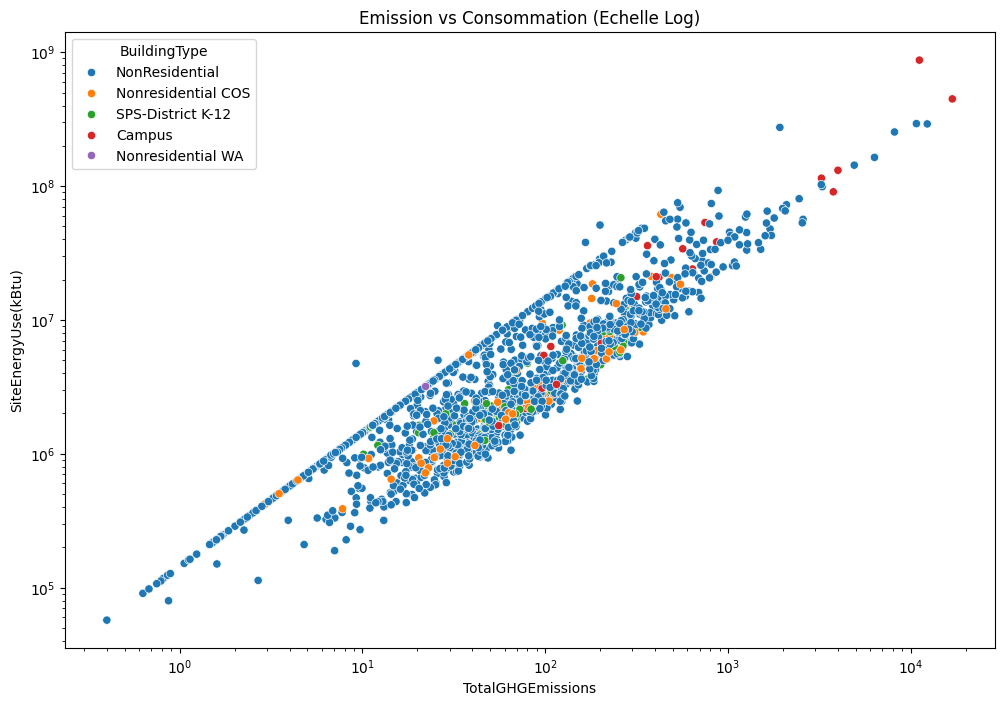

In [63]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_8_building_consumption, x='TotalGHGEmissions', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Emission vs Consommation (Echelle Log)')
plt.show()

Les deux variables sont effectivement très corrélés. On peut même se demande si la variable TotalGHGEmissions n'a pas été calculée sur la base de la consommation en énergie. Sinon comment aurait-on pu obtenir ces informations ? Jusqu'à preuve du contraire, on ne peut pas mesurer de manière réelle la quantité de gaz émise par une batiment.

Dans le cadre de notre étude, celle qui nous intéresse est clairement 'SiteEnergyUse(kBtu)' qui correspond à la consommation d'energie (en kBtu - kilobtus) de chaque batiment. Nous retiendrons donc 'SiteEnergyUse(kBtu)' et nous pouvons écarter TotalGHGEmissions. 

            b. Intensite des emissions (GHGEmissionsIntensity) et Consommation d'energie (SiteEnergyUse(kBtu) --> -1 variable

La variable GHGEmissionsIntensity étant dérivée de TotalGHGEmissions (en la rapportant par la surface), il y a également une redondance de données entre les deux variables.
On pourrait donc retrouver TotalGHGEmissions en multipliant GHGEmissionsIntensity par la surface, que l'on a gardé dans notre modèle. Cela reviendrait donc à garder TotalGHGEmissions que l'on a décidé de supprimer pour redondance de données.
--> On supprime donc également cette variable (GHGEmissionsIntensity) pour les mêmes raisons.

            c. Redondance entre Neighborhood (Quartier - 19 valeurs), ZipCode (Code Postal - 55 valeurs) et CouncilDistrictCode (Code District - 7 valeurs) --> -2 variables

Ces 3 variables donne des indications sur la localisation du batiment. De différentes manières :

- CouncilDistrictCode (Code du district administratif) : Avec 7 valeurs numérique, le code du district indique davantage une division politique/administrative. Bien qu'utile pour la mairie, elle n'a pas d'influence physique sur la consommation d'énergie d'un bâtiment. La météo ou l'âge des bâtiments ne s'arrêtent pas à la frontière d'un district du conseil municipal.

- Neighborhood (Quartier) : la Zone de voisinage, définie par le département des quartiers de la ville de Seattle, détermine veritablement une zone géographique. Avec 19 modalités sans aucun 'NaN' offre une granularité suffisante tout en garantissant que chaque quartier est bien représenté dans les données. De plus, il s'agit d'une variable "categorielle" sur laquelle le modèle peut apprendre facilement, sans transformations préalable.

- ZipCode (Code postal) : Même s'il est composé de chiffres, c'est bien une variable qualitative. Il renseigne également sur la localisation du batiment, au même titre que le Neighborhood. Cependant, il faudra donc le traiter en one-hot encoding comme n'importe quelle variable catégorielle sous forme de nombre. Avec 48 modalités, le one-hot encoding de ZipCode va créer 48 colonnes binaires dans la matrice. Avec seulement 1 649 bâtiments, certains ZipCodes auront très peu de représentants — quelques bâtiments par code postal — ce qui rend difficile pour le modèle d'apprendre un signal fiable sur ces modalités rares (problème de la sous-représentation).



On va vérifier la réprésentativité de chacune des variables pour voir celles qui a le plus de modalités "sous-représentés" c'est à dire avec moins de 10 individus associés.

In [64]:
# Vérifier la représentativité de chaque ZipCode
print(filtered_8_building_consumption['ZipCode'].value_counts())
print(f"\nNb de ZipCodes avec moins de 10 bâtiments : "
      f"{(filtered_8_building_consumption['ZipCode'].value_counts() < 10).sum()}\n\n")

print(filtered_8_building_consumption['Neighborhood'].value_counts())
print(f"\nNb de Neighborhoods avec moins de 10 bâtiments : "
      f"{(filtered_8_building_consumption['Neighborhood'].value_counts() < 10).sum()}")

ZipCode
98134.0    180
98104.0    155
98101.0    145
98109.0    138
98108.0    119
98122.0     89
98121.0     83
98105.0     83
98103.0     67
98119.0     62
98125.0     51
98115.0     50
98107.0     49
98133.0     49
98118.0     46
98144.0     46
98102.0     26
98106.0     25
98116.0     24
98199.0     21
98126.0     21
98112.0     20
98117.0     18
98195.0      9
98136.0      6
98155.0      4
98178.0      3
98154.0      2
98111.0      2
98168.0      2
98124.0      2
98013.0      2
98146.0      2
98177.0      2
98070.0      1
98033.0      1
98191.0      1
98164.0      1
98185.0      1
98181.0      1
98006.0      1
98053.0      1
98114.0      1
98165.0      1
98011.0      1
98113.0      1
98020.0      1
98145.0      1
Name: count, dtype: int64

Nb de ZipCodes avec moins de 10 bâtiments : 25


Neighborhood
DOWNTOWN                  354
GREATER DUWAMISH          342
LAKE UNION                147
MAGNOLIA / QUEEN ANNE     147
NORTHEAST                 125
EAST                      120
NOR

Zip Code est clairement la variable la plus mal représentée avec 25 variables associée à moins de 10 batiments, contre 6 pour la variable Neighborhood. On écarte donc Zip Code au profit de Neighborhood.

On décide donc (plus ou moins arbitrairement) de supprimer les variable 'CouncilDistrictCode' et 'ZipCode' pour ne laisser que 'Neighborhood' ainsi que longitude et latitude car il renseigne sur la position exacte.

In [65]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'TotalGHGEmissions', 
    'GHGEmissionsIntensity', 
    'CouncilDistrictCode',
    'ZipCode'
]

filtered_9_building_consumption = filtered_8_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_9_building_consumption.shape[1]}")

Nombre de colonnes restantes : 25


        c. Filtrages complémentaires

On regarde désormais les colonnes restantes et le nombre de valeurs manquantes par colonne :

In [66]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_9_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_9_building_consumption.isnull().sum() / len(filtered_9_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
ThirdLargestPropertyUseType               1282                           78.51
ThirdLargestPropertyUseTypeGFA            1282                           78.51
SecondLargestPropertyUseTypeGFA            786                           48.13
SecondLargestPropertyUseType               786                           48.13
ENERGYSTARScore                            551                           33.74
LargestPropertyUseType                       4                            0.24
LargestPropertyUseTypeGFA                    4                            0.24
PrimaryPropertyType                          0                            0.00
BuildingType                                 0                            0.00
PropertyGFATotal                             0                            0.00
NumberofFloors                               0                            0.00
NumberofBuildings                            0      

            1. Variables 'DefaultData' et 'ComplianceStatus'

                a. Lignes associées aux valeurs 'true' et 'ComplianceStatus'

Pour rappel, les variables Default Data et Compliance Status ont les descriptions suivantes : 
- DefaultData est un flag booléen qui indique que les données du bâtiment sont des valeurs par défaut estimées par la ville, et non des relevés réels. 'True' si c'est le cas, 'False' dans le cas contraire.
- ComplianceStatus : Statut de conformité du bâtiment vis-à-vis de la loi sur le benchmarking (Compliant/Nom-Compliant/Error - Correct Default Data/Missing Data). 'Compliant' si un immeuble respecte les exigences de référence en matière d'énergie pour l'année de déclaration spécifiée. 'Error - Correct Default Data' si les données n'ont pas permi d'obtenir ce statut.

Voyons les occurences de ces valeurs pour chacune de ces variables. 

In [67]:
print(filtered_8_building_consumption['DefaultData'].value_counts())
print(filtered_8_building_consumption['ComplianceStatus'].value_counts())

DefaultData
False    1548
True       85
Name: count, dtype: int64
ComplianceStatus
Compliant                       1548
Error - Correct Default Data      85
Name: count, dtype: int64


Voyons maintenant si les valeurs de ces variables sont corrélés pour détecter une éventuelle signification et redondance de données. 

In [68]:
# Vérification de la redondance
print(pd.crosstab(filtered_9_building_consumption['DefaultData'], filtered_9_building_consumption['ComplianceStatus']))

ComplianceStatus  Compliant  Error - Correct Default Data
DefaultData                                              
False                  1548                             0
True                      0                            85


Les valeurs à True pour la variable DefaultData concernent exactement les mêmes lignes (individus) que celles à 'Error - Correct Default Data' pour la variable ComplianceStatus. Cela signifie que ces lignes sont bien concernés par un problème de données qui peut poser problème dans notre modèle de par prédiction. De par le faible nombre de ces individus, nous pouvons tout simplement les supprimer.

In [69]:
# Suppression des consommations nulles ou négatives (incohérent pour un bâtiment actif)
len_filtered_9_building_consumption = len(filtered_9_building_consumption)
print(f"Lignes initiales : {len_filtered_9_building_consumption}")
filtered_10_building_consumption = filtered_9_building_consumption[filtered_9_building_consumption['DefaultData'] == False]
#On aurait également filtrer sur la colonne ComplianceStatus car les deux variables sont 100% corrélés sur ces modalités
#filtered_10_building_consumption = filtered_9_building_consumption[filtered_9_building_consumption['ComplianceStatus'] = 'Error - Correct Default Data']
len_filtered_10_building_consumption = len(filtered_10_building_consumption)
print(f"Après diziaine filtrage (DefaultData - False) : {len_filtered_10_building_consumption}")

Lignes initiales : 1633
Après diziaine filtrage (DefaultData - False) : 1548


                b. Colonnes associés aux variables DefaultData et ComplianceStatus --> -2 variables

Etant donné que l'on a supprimé les modalités 'False' et 'Error - Correct Default Data' des variables DefaultData et ComplianceStatus, il ne reste plus qu'une modalité pour chacune des deux variables soit une variance nulle. Par conséquent, on peut supprimer ces deux variables.

In [70]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'DefaultData', 
    'ComplianceStatus', 
]

filtered_11_building_consumption = filtered_10_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_11_building_consumption.shape[1]}")

Nombre de colonnes restantes : 23


                    c. Colonne 'ListOfAllPropertyUseTypes'

Même si cette colonne semble pertinente, elle n'est pas adaptée dans le cadre de notre modèle de prédiction. En effet c'est une chaîne de caractères brute (ex: "Hotel, Restaurant, Parking"). Pour un modèle de ML, c'est inexploitable tel quel. Dans la mesure où l'on a déjà les colonnes LargestPropertyUseType, Second..., etc., cette liste n'apporte aucune information structurée supplémentaire. Nous pouvons donc la supprimer. 

In [71]:
cols_to_drop = [
    'ListOfAllPropertyUseTypes'
]

filtered_12_building_consumption = filtered_11_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_12_building_consumption.shape[1]}")

Nombre de colonnes restantes : 22


On regarde désormais les colonnes restantes le nombre et le taux de valeurs manquantes associées.

In [72]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_12_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_12_building_consumption.isnull().sum() / len(filtered_12_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
ThirdLargestPropertyUseType               1200                           77.52
ThirdLargestPropertyUseTypeGFA            1200                           77.52
SecondLargestPropertyUseTypeGFA            706                           45.61
SecondLargestPropertyUseType               706                           45.61
ENERGYSTARScore                            551                           35.59
LargestPropertyUseType                       4                            0.26
LargestPropertyUseTypeGFA                    4                            0.26
Longitude                                    0                            0.00
YearBuilt                                    0                            0.00
Neighborhood                                 0                            0.00
PrimaryPropertyType                          0                            0.00
BuildingType                                 0      

                    d. Longitude et Latitude

En ce qui concerne la localisation, on a gardé l'information 'Neighborhood' car elle representait un bon compromis de granularité entre 'CouncilDistrictCode', qui ne présentait que 7 modalités et 'ZipCode' qui en presentait 48.
Par conséquent, on a déjà une bonne information sur la localisation. La positiion exacte (avec la longitude et la latitude) présente un fort risque de surapprentissage. D'autant plus que c'est deux valeurs n'ont pas forcément de sens en terme de 'grandeur'. En effet une latitude elevé pourra représenter, de manière aléatoire, soit une positition près d'un centre ville entourné d'immeuble et bien préservé du vent, soit une position près de l'eau et totalement exposé au vent et aux intempéries (ce qui nécessitera une consommation d'energie plus elevé). Par conséquent, cette information telle qu'elle n'a pas de sens.

Une alternative consisterait à calculer, via ces informations, la distance par rapport au centre géographique de la ville. Le résultat serait bel et bien une mesure qui représenterait une grandeur : "plus la distance est grande plus on s'eloigne du centre". Cependant, est-ce que s'éloigner du centre signifie nécessairement avoir une consommation énergetique plus élevé ? Ou inversemment ? Pas nécessairement, pour les mêmes raisons que précedemment : Une grande distance par rapport au centre peut aboutir à des situations géographiques totalement différentes (soit très exposé, soit totalement protégé des intempéries). Si on avait été au centre d'une ile avec peu ou pas de relief, cela aurait été différent, mais ce n'est pas le cas pour Seattle !

Avant de supprimer purement et simplement ces variables, nous allons tout de même vérifier la corrélation entre la consommation totale d'energie SiteEnergyUse(kBtu), la longitude et la latitude.

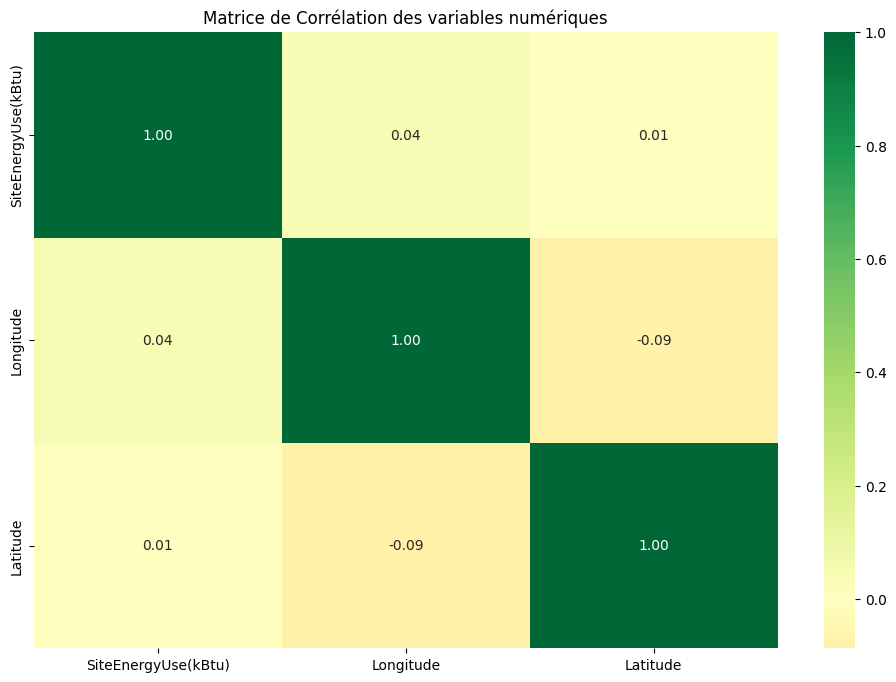

In [73]:
# On ne garde que les colonnes numériques pour la corrélation
cols_num = [
    'SiteEnergyUse(kBtu)', 'Longitude', 'Latitude'
]

# Calcul de la matrice de corrélation
corr = filtered_12_building_consumption[cols_num].corr()

# Affichage
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matrice de Corrélation des variables numériques')
plt.show()

Les corrélations entre la consommation totale d'energie SiteEnergyUse(kBtu) et la latitude ainsi que la longitude ne dépasse pas le taux de 0.04 ce qui est excessivement faible, voire quasiment nul. Par conséquent, nous pouvons supprimer ces deux variables sans trop d'inquiétude sur la perte d'information.

In [74]:
cols_to_drop = [
    'Longitude', 'Latitude'
]

filtered_13_building_consumption = filtered_12_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_13_building_consumption.shape[1]}")

Nombre de colonnes restantes : 20


In [75]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_13_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_13_building_consumption.isnull().sum() / len(filtered_12_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
ThirdLargestPropertyUseType               1200                           77.52
ThirdLargestPropertyUseTypeGFA            1200                           77.52
SecondLargestPropertyUseTypeGFA            706                           45.61
SecondLargestPropertyUseType               706                           45.61
ENERGYSTARScore                            551                           35.59
LargestPropertyUseType                       4                            0.26
LargestPropertyUseTypeGFA                    4                            0.26
BuildingType                                 0                            0.00
YearBuilt                                    0                            0.00
Neighborhood                                 0                            0.00
PrimaryPropertyType                          0                            0.00
NumberofBuildings                            0      

In [76]:
print(filtered_13_building_consumption['BuildingType'].value_counts())

BuildingType
NonResidential        1432
Nonresidential COS      81
Campus                  24
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64


In [77]:
print(filtered_13_building_consumption['PrimaryPropertyType'].value_counts())

PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             2
Name: count, dtype: int64


4. Visualisations pertinentes (après filtrage)

Après ces différents filtrages, il peut intéressant d'observer la distribution de certaines variables ou la correlations de plusieurs variables entre elles. Cela s'opère sur une effectif réduit d'individus et donne plus de sens aux différentes différentes représentations obtenus sur ces graphiques. 

    a. La distribution (du logarithme naturel) de la consommation énergetique (cible)

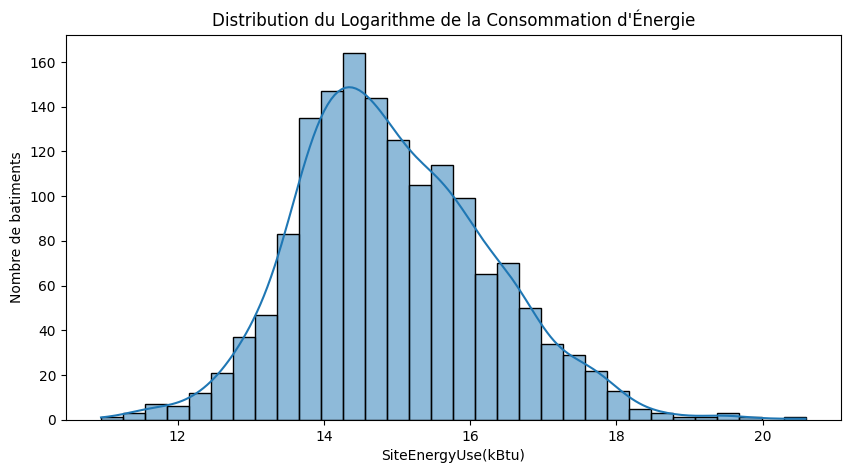

In [78]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(filtered_13_building_consumption['SiteEnergyUse(kBtu)']), kde=True)
plt.ylabel("Nombre de batiments")
#sns.histplot(filtered_13_building_consumption['SiteEnergyUse(kBtu)'], kde=True)
plt.title('Distribution du Logarithme de la Consommation d\'Énergie')
plt.show()

    b. Relations entre Surface et Consommation par type de bâtiment, normalisé par le logarithme.

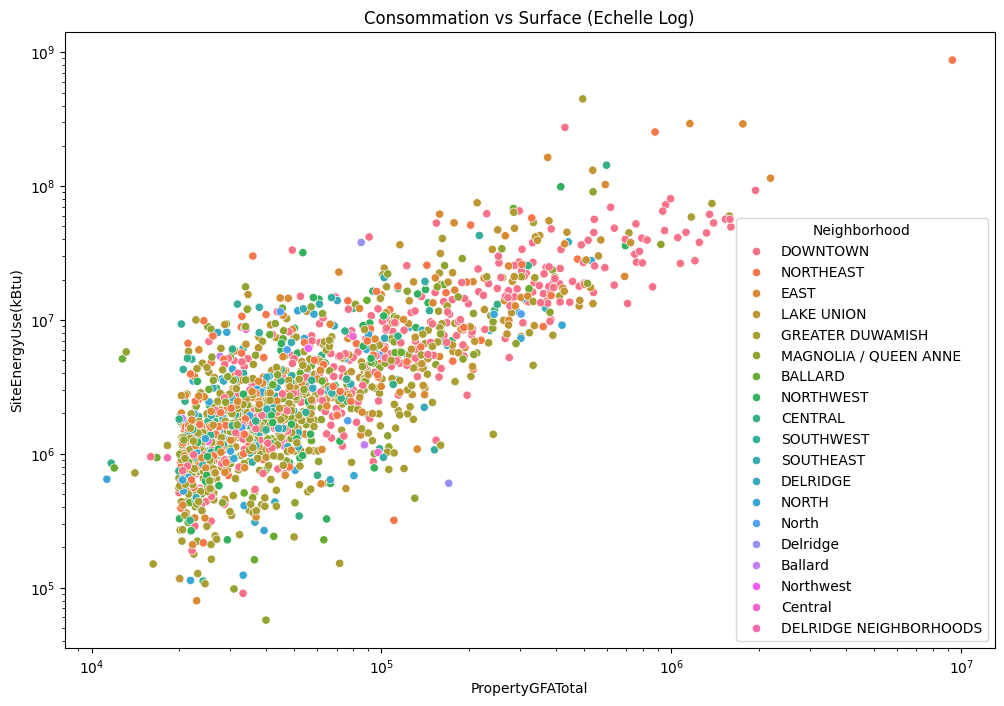

In [79]:
plt.figure(figsize=(12, 8))
#sns.scatterplot(data=filtered_13_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='BuildingType')
sns.scatterplot(data=filtered_13_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='Neighborhood')
plt.xscale('log')
plt.yscale('log')
plt.title('Consommation vs Surface (Echelle Log)')
plt.show()

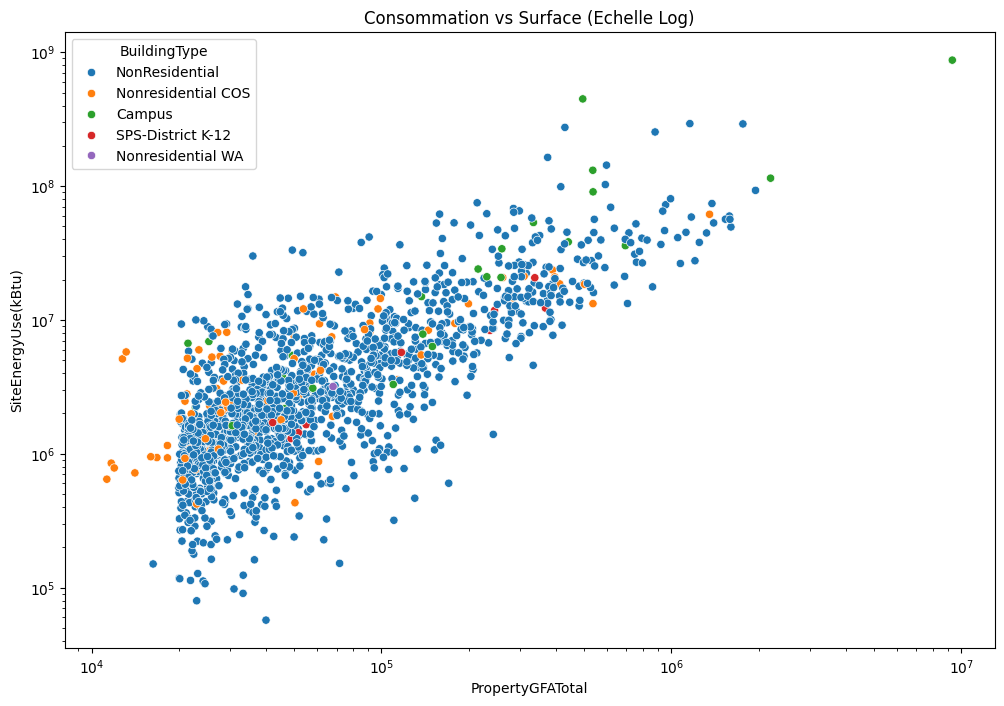

In [80]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_12_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Consommation vs Surface (Echelle Log)')
plt.show()

        c. Corrélations entre les variables quantitative

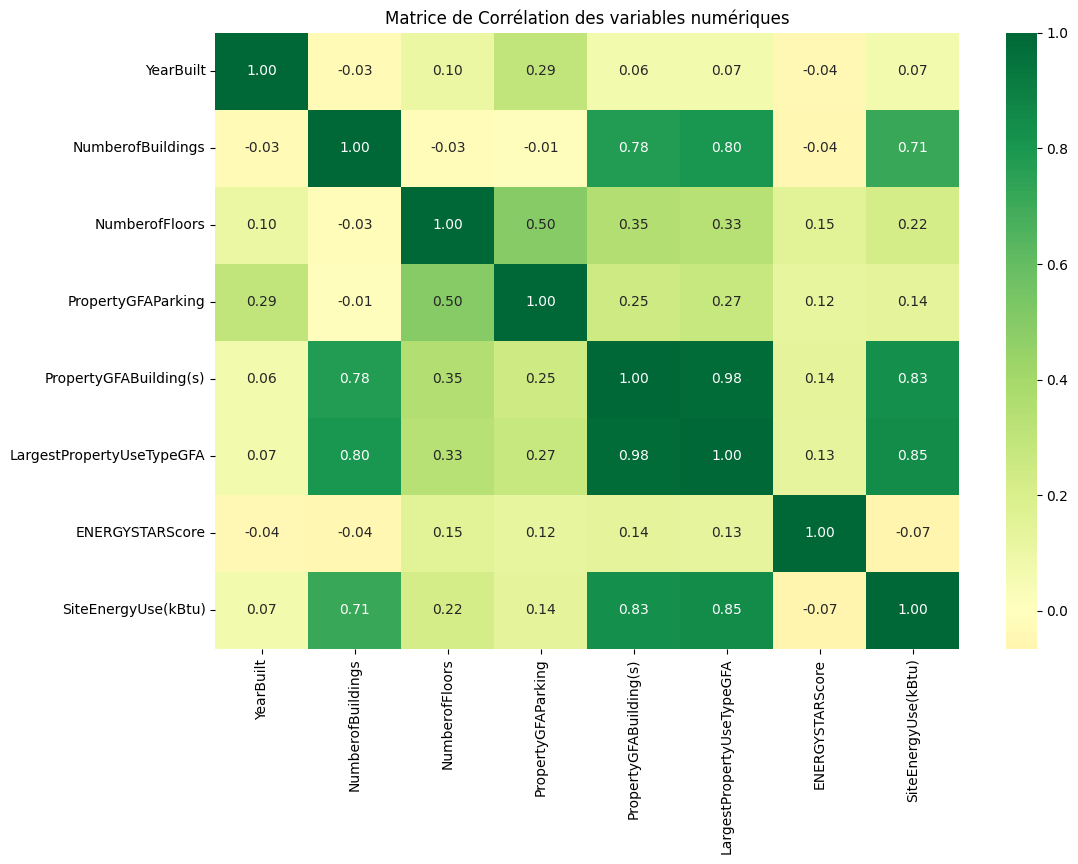

In [81]:
# On ne garde que les colonnes numériques pour la corrélation
cols_num = [
    'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 
    'PropertyGFAParking', 'PropertyGFABuilding(s)', 
    'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 
    'SiteEnergyUse(kBtu)'
]

# Calcul de la matrice de corrélation
corr = filtered_13_building_consumption[cols_num].corr()

# Affichage
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matrice de Corrélation des variables numériques')
plt.show()

# Modélisation 

### Import des modules 

In [82]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

1. Variables Has_Steam, Has_Gas et Has_Electricity

Dans la mesure ou nous devions supprimer les colonnes de consommations d'electricicté,de gaz et de vapeur, il était nécessaire de sauvegarder l'information qui renseigne sur l'accès des batiments à ces 3 énergies/ Nous avons donc crée les variables Has_Steam, Has_Gas et Has_Electricity. C'était du Feature Engineering avant l'heure !

2. Variables LargestPropertyUseType, SecondLargestPropertyUseType, ThirdLargestPropertyUseType et LargestPropertyUseTypeGFA, LargestPropertyUseTypeGFA, SecondLargestPropertyUseTypeGFA, ThirdLargestPropertyUseType.

Commençons par voir ce qu'il y a comme modalités dans chacune des variables LargestPropertyUseType, SecondLargestPropertyUseType et ThirdLargestPropertyUseType :

On commence par regarder les occurences et les catégories en incluant les valeurs manquantes (NaN) qui nous renseigne aussi sur la qualité de chaque variable.

In [83]:
cols_use_type = [
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType',
]

for col in cols_use_type:
    counts = filtered_13_building_consumption[col].value_counts(dropna=False)
    
    print(f"{'='*60}")
    print(f"{col}")
    print(f"\nNombre total de catégories uniques (incluant NaN) : {len(counts)}")
    print(f"({len(filtered_13_building_consumption)} bâtiments au total)")
    print(f"{'─'*60}")
    print(f"{'Modalité':<45} {'Occurences':>5}  {'%':>6}")
    print(f"{'─'*60}")
    
    for modalite, n in counts.items():
        pct = n / len(filtered_13_building_consumption) * 100
        label = str(modalite) if pd.notna(modalite) else 'NaN'
        print(f"{label:<45} {n:>5}  {pct:>5.1f}%")
    
    print()

LargestPropertyUseType

Nombre total de catégories uniques (incluant NaN) : 56
(1548 bâtiments au total)
────────────────────────────────────────────────────────────
Modalité                                      Occurences       %
────────────────────────────────────────────────────────────
Office                                          485   31.3%
Non-Refrigerated Warehouse                      197   12.7%
Other                                            95    6.1%
Retail Store                                     93    6.0%
Hotel                                            75    4.8%
Worship Facility                                 69    4.5%
Distribution Center                              54    3.5%
K-12 School                                      50    3.2%
Medical Office                                   41    2.6%
Supermarket/Grocery Store                        41    2.6%
Other - Recreation                               31    2.0%
Parking                                         

On fait désormais la même chose en ne prenant pas en compte les valeurs NaN 

In [84]:
cols_use_type = [
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType',
]

for col in cols_use_type:
    total = filtered_13_building_consumption[col].notna().sum()  # on exclut les NaN du dénominateur
    counts = filtered_13_building_consumption[col].value_counts(dropna=True)
    
    print(f"{'='*60}")
    print(f"{col}")
    print(f"\nNombre total de catégories uniques (excluant NaN) : {len(counts)}")
    print(f"({total} bâtiments renseignés sur {len(filtered_13_building_consumption)})")
    print(f"{'─'*60}")
    print(f"{'Modalité':<45} {'Occurences':>5}  {'%':>6}")
    print(f"{'─'*60}")
    
    for modalite, n in counts.items():
        pct = n / total * 100
        print(f"{modalite:<45} {n:>5}  {pct:>5.1f}%")
    
    print()

LargestPropertyUseType

Nombre total de catégories uniques (excluant NaN) : 55
(1544 bâtiments renseignés sur 1548)
────────────────────────────────────────────────────────────
Modalité                                      Occurences       %
────────────────────────────────────────────────────────────
Office                                          485   31.4%
Non-Refrigerated Warehouse                      197   12.8%
Other                                            95    6.2%
Retail Store                                     93    6.0%
Hotel                                            75    4.9%
Worship Facility                                 69    4.5%
Distribution Center                              54    3.5%
K-12 School                                      50    3.2%
Medical Office                                   41    2.7%
Supermarket/Grocery Store                        41    2.7%
Other - Recreation                               31    2.0%
Parking                              

Avant de faire une quelconque transformation, on va regarder si les modalités contenus dans la variable PrimaryPropertyType se rapproche de celle que l'on a déjà énoncé pour la variable LargestPropertyUseType.

In [85]:
counts = filtered_13_building_consumption["PrimaryPropertyType"].value_counts(dropna=False)

print(f"{'='*60}")
print(f"PrimaryPropertyType")
print(f"\nNombre total de catégories uniques (incluant NaN) : {len(counts)}")
print(f"({len(filtered_13_building_consumption)} bâtiments au total)")
print(f"{'─'*60}")
print(f"{'Modalité':<45} {'Occurences':>5}  {'%':>6}")
print(f"{'─'*60}")

for modalite, n in counts.items():
    pct = n / len(filtered_13_building_consumption) * 100
    label = str(modalite) if pd.notna(modalite) else 'NaN'
    print(f"{label:<45} {n:>5}  {pct:>5.1f}%")

print()

PrimaryPropertyType

Nombre total de catégories uniques (incluant NaN) : 21
(1548 bâtiments au total)
────────────────────────────────────────────────────────────
Modalité                                      Occurences       %
────────────────────────────────────────────────────────────
Small- and Mid-Sized Office                     286   18.5%
Other                                           245   15.8%
Warehouse                                       185   12.0%
Large Office                                    169   10.9%
Mixed Use Property                              113    7.3%
Retail Store                                     85    5.5%
Hotel                                            75    4.8%
Worship Facility                                 69    4.5%
Distribution Center                              53    3.4%
K-12 School                                      50    3.2%
Supermarket / Grocery Store                      40    2.6%
Medical Office                                   39

On va désormais regarder les ressemblances de cette colonne avec LargestPropertyUseType, car elles sont censées représenter la même information au final : l'utilisation principale du batiment, son usage premier, sa fonctionnalité première, qui est censé être identique avec l'usage de première superficie, soit l'usage qui est fait sur la majorité de sa surface.

Cependant, nous ne sommes pas surs que les catégories  soient identiques. Déjà parce que le nombre de modalités n'est pas le même (56 pour LargestPropertyUseType contre 21 pour le PrimaryPropertyType. Et aussi parce que ces deux informations ne sont pas forcement de même nature. Si on reprend les définitions que l'on a donné :
-PrimaryPropertyType : C'est la classification "administrative" du bâtiment. C'est l'étiquette donnée au bâtiment dans son ensemble (ex: "Hôtel").
-LargestPropertyUseType : C'est l'usage qui occupe le plus de surface au sol (m2) constaté dans la réalité.

Par conséquent, on va analyser le taux de corrélation de ces deux variables, pour voir si leurs valeurs se recoupent effectivement.

In [86]:
# On crée une colonne de comparaison
match_series = (filtered_13_building_consumption['PrimaryPropertyType'] == filtered_13_building_consumption['LargestPropertyUseType'])

# Calcul du pourcentage de correspondance
match_rate = match_series.mean() * 100

print(f"Taux de correspondance exacte : {match_rate:.2f}%")

# Affichage des cas où cela diffère pour comprendre pourquoi
diff_df = filtered_13_building_consumption[~match_series][['PrimaryPropertyType', 'LargestPropertyUseType']].head(10)
print("\nExemples de divergences :")
print(diff_df)

Taux de correspondance exacte : 34.43%

Exemples de divergences :
            PrimaryPropertyType                 LargestPropertyUseType
5                         Other                         Police Station
7                         Other  Other - Entertainment/Public Assembly
15                        Other                                Library
16                        Other         Fitness Center/Health Club/Gym
18           Mixed Use Property                    Social/Meeting Hall
20                        Other                             Courthouse
24                   University                     College/University
25                        Other                  Automobile Dealership
32  Small- and Mid-Sized Office                                 Office
35           Mixed Use Property                                 Office


Le taux de corrélation est de 34.43%. Un taux de 34 % est extrêmement faible, ce qui signifie que dans deux tiers des cas, l'étiquette administrative du bâtiment (PrimaryPropertyType) ne correspond pas à l'activité qui occupe le plus de surface au sol (LargestPropertyUseType). Cela s'explique par le fait qu'un bâtiment peut être classé administrativement comme "Small-sized Office" (PrimaryPropertyType), mais son usage principal réel peut être "Parking" ou "Retail Store" s'il y a des commerces en bas. 

Si on garde PrimaryPropertyType, on risque de donner au modèle une étiquette qui ne reflète pas la réalité physique (thermique) du bâtiment et on risque également de créer la confusion avec l'usage réelle. Par conséquent, voici les deux actions auxquelles on va procéder :

- supprimer la variable PrimaryPropertyType. Elle apporte trop de confusion et de "bruit" statistique qui n'a pas de signification dans le cadre de notre étude : un catégorisation administrative ne réprésente pas l'usage réel !
- Privilégier LargestPropertyUseType, SecondLargestPropertyUseType et ThirdLargestPropertyUseType : La consommation d'énergie est dictée par ce qu'on fait à l'intérieur des surfaces (chauffer un entrepôt vs éclairer un bureau), pas par le nom administratif sur le permis de construire.
- Utiliser les variables LargestPropertyUseTypeGFA, SecondLargestPropertyUseTypeGFA et ThirdLargestPropertyUseTypeGFA. Par exemple, LargestPropertyUseType est directement couplé à LargestPropertyUseTypeGFA. Si on prédit la consommation, on a besoin que l'usage et la surface soient alignés.
- Transformer ces 6 variables afin de synthétiser l'information et la rendre plus "utilisable" par le modèle : On va fusionner les usages avec les surfaces d'usages en créeant une colonne par modalité (de la variable LargestPropertyUseType) et mettre la surface utilisée dans le réel par chaque modalité (chaque usage). Cela nous donnera l'information réelle d'utilisation par la surface, ce qui renseignera de fait sur l'ordre d'usage (toujours par cette même surface d'utilisation).
- Regrouper les 56 modalités en catégories plus grandes, de telle manière d'éviter des modalités qui sont peu réprésentés ou qui pourraient être regroupés avec d'autres en terme de type d'usage et de consommation. Cela permettra de passer de 56 nouvelles variables à une dizaine environ, ce qui est nettement plus digeste pour le modèle de prédiction.

Avantage : En supprimant PrimaryPropertyType, On peut-être une info sur la gestion globale du bâtiment, mais on gagne énormément en précision physique. Pour un modèle qui doit prédire des kBtu, la précision physique gagne toujours sur l'étiquette administrative. Par ailleurs, en créant ces nouvelles colonnes de surfaces par type, on a plus à choisir entre l'une ou l'autre variable. Notre modèle verra, par exemple : Bâtiment A : 2000 m2 de Bureaux + 500 m2 de Parking. Peu importe qu'il s'appelle administrativement "Hôtel" ou "Bureau", le modèle aura la réalité des surfaces.

On va déjà supprimer la colonne PrimaryPropertyType pour alléger immédiatement le modèle :

In [87]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'PrimaryPropertyType'
]

filtered_14_building_consumption = filtered_13_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_14_building_consumption.shape[1]}")

Nombre de colonnes restantes : 19


Création de catégories pour les modalités des variables LargestPropertyUseType, SecondLargestPropertyUseType et ThirdLargestPropertyUseType.

--> Ces modalités sont les mêmes, c'est juste qu'il y en a plus dans LargestPropertyUseType que dans les autres. On prend LargestPropertyUseType car c'est le plus large en terme de modalités. Voilà une proposition de regroupement en 9 catéogries. : 

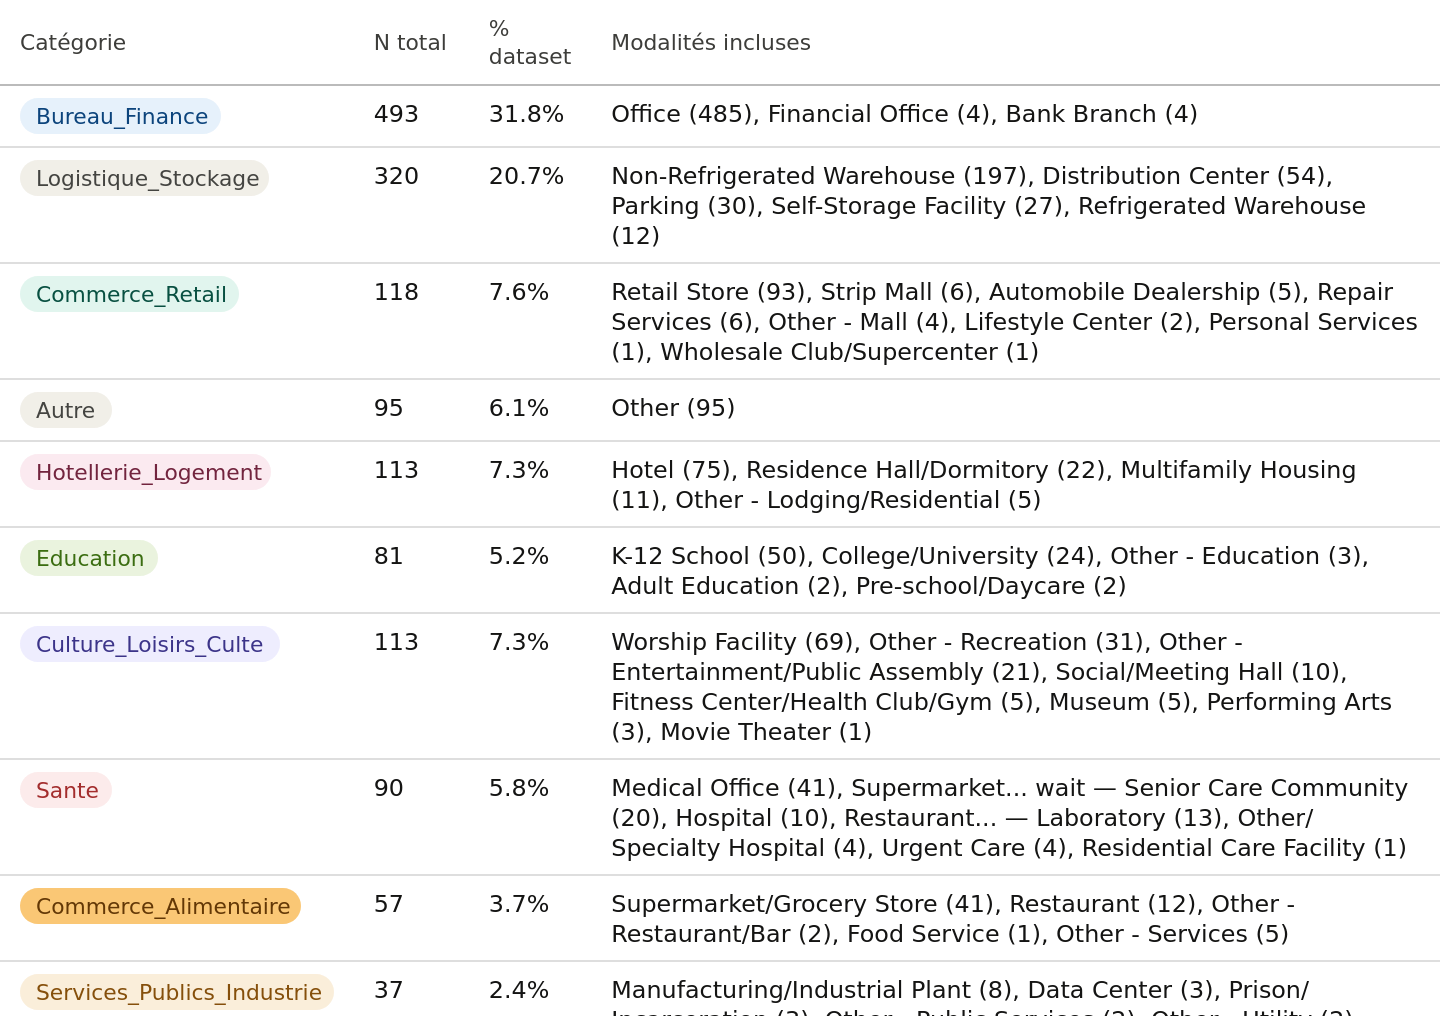


Ce regroupement a été fait en utilisant les modalités de LargestPropertyUseType, car elles sont plus nombreuses que dans les autres variables SecondLargestPropertyUseType et ThirdLargestPropertyUseType. Cependant, après analyse, je me suis rendu compte que certaines modalités de SecondLargestPropertyUseType et ThirdLargestPropertyUseType n'étaient pas présentes dans celles de LargestPropertyUseType. Voici ces modalités et comment on les place dans le regroupement proposée précedemment :

- CULTURE_LOISIRS_CULTE : Swimming Pool
- COMMERCE_ALIMENTAIRE : Bar/Nightclub, Food Sales, Convenience Store without Gas Station, Fast Food Restaurant
- EDUCATION : Vocational School
- COMMERCE_RETAIL : Enclosed Mall
- SERVICES_PUBLICS_INDUSTRIE : Other - Technology/Science

On fait donc le mapping python permettant d'associer aux anciennes modalités des variables les nouvelles catégories énoncées précedemment.

In [88]:
#1. Définition du mapping en fonction des nouvelles catégories définies ci-dessus
mapping_usage = {
    # Bureau / Finance
    'Office'                                              : 'Bureau_Finance',
    'Financial Office'                                    : 'Bureau_Finance',
    'Bank Branch'                                         : 'Bureau_Finance',

    # Logistique / Stockage
    'Non-Refrigerated Warehouse'                          : 'Logistique_Stockage',
    'Distribution Center'                                 : 'Logistique_Stockage',
    'Parking'                                             : 'Logistique_Stockage',
    'Self-Storage Facility'                               : 'Logistique_Stockage',
    'Refrigerated Warehouse'                              : 'Logistique_Stockage',

    # Commerce / Retail
    'Retail Store'                                        : 'Commerce_Retail',
    'Strip Mall'                                          : 'Commerce_Retail',
    'Automobile Dealership'                               : 'Commerce_Retail',
    'Repair Services (Vehicle, Shoe, Locksmith, etc)'     : 'Commerce_Retail',
    'Other - Mall'                                        : 'Commerce_Retail',
    'Other - Services'                                    : 'Commerce_Retail',
    'Lifestyle Center'                                    : 'Commerce_Retail',
    'Personal Services (Health/Beauty, Dry Cleaning, etc)': 'Commerce_Retail',
    'Wholesale Club/Supercenter'                          : 'Commerce_Retail',
    'Enclosed Mall'                                       : 'Commerce_Retail',

    # Hôtellerie / Logement
    'Hotel'                                               : 'Hotellerie_Logement',
    'Residence Hall/Dormitory'                            : 'Hotellerie_Logement',
    'Multifamily Housing'                                 : 'Hotellerie_Logement',
    'Other - Lodging/Residential'                         : 'Hotellerie_Logement',

    # Éducation
    'K-12 School'                                         : 'Education',
    'College/University'                                  : 'Education',
    'Other - Education'                                   : 'Education',
    'Adult Education'                                     : 'Education',
    'Pre-school/Daycare'                                  : 'Education',
    'Vocational School'                                   : 'Education',

    # Culture / Loisirs / Culte
    'Worship Facility'                                    : 'Culture_Loisirs_Culte',
    'Other - Recreation'                                  : 'Culture_Loisirs_Culte',
    'Other - Entertainment/Public Assembly'               : 'Culture_Loisirs_Culte',
    'Social/Meeting Hall'                                 : 'Culture_Loisirs_Culte',
    'Fitness Center/Health Club/Gym'                      : 'Culture_Loisirs_Culte',
    'Museum'                                              : 'Culture_Loisirs_Culte',
    'Performing Arts'                                     : 'Culture_Loisirs_Culte',
    'Movie Theater'                                       : 'Culture_Loisirs_Culte',
    'Swimming Pool'                                       : 'Culture_Loisirs_Culte',

    # Santé
    'Medical Office'                                      : 'Sante',
    'Senior Care Community'                               : 'Sante',
    'Hospital (General Medical & Surgical)'               : 'Sante',
    'Laboratory'                                          : 'Sante',
    'Other/Specialty Hospital'                            : 'Sante',
    'Urgent Care/Clinic/Other Outpatient'                 : 'Sante',
    'Residential Care Facility'                           : 'Sante',

    # Commerce alimentaire
    'Supermarket/Grocery Store'                           : 'Commerce_Alimentaire',
    'Restaurant'                                          : 'Commerce_Alimentaire',
    'Other - Restaurant/Bar'                              : 'Commerce_Alimentaire',
    'Food Service'                                        : 'Commerce_Alimentaire',
    'Bar/Nightclub'                                       : 'Commerce_Alimentaire',
    'Food Sales'                                          : 'Commerce_Alimentaire',
    'Convenience Store without Gas Station'               : 'Commerce_Alimentaire',
    'Fast Food Restaurant'                                : 'Commerce_Alimentaire',

    # Services publics / Industrie
    'Manufacturing/Industrial Plant'                      : 'Services_Publics_Industrie',
    'Data Center'                                         : 'Services_Publics_Industrie',
    'Prison/Incarceration'                                : 'Services_Publics_Industrie',
    'Other - Public Services'                             : 'Services_Publics_Industrie',
    'Other - Utility'                                     : 'Services_Publics_Industrie',
    'Police Station'                                      : 'Services_Publics_Industrie',
    'Courthouse'                                          : 'Services_Publics_Industrie',
    'Fire Station'                                        : 'Services_Publics_Industrie',
    'Other - Technology/Science'                          : 'Services_Publics_Industrie',
    'Library'                                             : 'Services_Publics_Industrie',

    # Autre
    'Other'                                               : 'Autre',
}

Désormais on va écrire le code qui va permettre de procéder la transformation des données étape par étape :
- créer une nouvelle colonne 'GFA_{cat}' pour la superficie associée à chaque nouvelle catégorie. Elles seront initialisées à '0'.
- Récuperer les 3 usages et leur superficie associée et renseigner cette superficie dans la bonne catégorie grâce au mmapping.
- N'executer ce deuxième traitement que pour les usages non vides et les surperficies non vides et supérieures à 0.

In [89]:
# 2. Création des colonnes de surface (GFA) initialisées à 0
# On récupère les valeurs uniques de notre mapping + 'Autre'
filtered_15_building_consumption = filtered_14_building_consumption.copy()
macro_categories = list(set(mapping_usage.values()))
for cat in macro_categories:
    filtered_15_building_consumption[f'GFA_{cat}'] = 0.0

In [90]:
filtered_15_building_consumption.head()

,BuildingType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,...,GFA_Logistique_Stockage,GFA_Hotellerie_Logement,GFA_Commerce_Retail,GFA_Sante,GFA_Commerce_Alimentaire,GFA_Autre,GFA_Culture_Loisirs_Culte,GFA_Services_Publics_Industrie,GFA_Bureau_Finance,GFA_Education
0,NonResidential,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,88434.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NonResidential,DOWNTOWN,1996,1.0,11,103566,15064,88502,Hotel,83880.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NonResidential,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,756493.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NonResidential,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,61320.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NonResidential,DOWNTOWN,1980,1.0,18,175580,62000,113580,Hotel,123445.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
# 3. Remplissage itératif
for rank in ['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']:
    gfa_col = rank + 'GFA'
    
    for idx in filtered_15_building_consumption.index:
        usage = filtered_15_building_consumption.at[idx, rank]
        surface = filtered_15_building_consumption.at[idx, gfa_col]
        
        if pd.notna(usage) and pd.notna(usage) and surface > 0:
            # On cherche dans le mapping, sinon on met dans 'Autre'
            category = mapping_usage.get(usage, 'Autre')
            filtered_15_building_consumption.at[idx, f'GFA_{category}'] += surface

In [92]:
# 1. Préparation de la liste des colonnes
anciennes_cols = [
    'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA'
]

# On récupère dynamiquement tes 10 nouvelles colonnes GFA
nouvelles_cols = [col for col in filtered_15_building_consumption.columns if col.startswith('GFA_')]

# 2. Visualisation d'un échantillon de 10 bâtiments
# .sample(10) permet de tomber sur des cas variés (mixtes ou non)
verification_df = filtered_15_building_consumption[anciennes_cols + nouvelles_cols].sample(10)

# 3. Affichage propre
print("--- VÉRIFICATION DES CALCULS (ÉCHANTILLON) ---")
display(verification_df)

--- VÉRIFICATION DES CALCULS (ÉCHANTILLON) ---


,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,GFA_Logistique_Stockage,GFA_Hotellerie_Logement,GFA_Commerce_Retail,GFA_Sante,GFA_Commerce_Alimentaire,GFA_Autre,GFA_Culture_Loisirs_Culte,GFA_Services_Publics_Industrie,GFA_Bureau_Finance,GFA_Education
3275,College/University,58779.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58779.0
2564,Retail Store,19240.0,Office,2050.0,Medical Office,1250.0,0.0,0.0,19240.0,1250.0,0.0,0.0,0.0,0.0,2050.0,0.0
894,College/University,28800.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28800.0
1839,Multifamily Housing,12000.0,Office,8262.0,Retail Store,6312.0,0.0,12000.0,6312.0,0.0,0.0,0.0,0.0,0.0,8262.0,0.0
2001,Retail Store,22740.0,Office,4860.0,NaN,NaN,0.0,0.0,22740.0,0.0,0.0,0.0,0.0,0.0,4860.0,0.0
204,Office,383942.0,Parking,127192.0,NaN,NaN,127192.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,383942.0,0.0
52,Hotel,70627.0,Parking,42546.0,NaN,NaN,42546.0,70627.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307,Medical Office,270384.0,Parking,270383.0,NaN,NaN,270383.0,0.0,0.0,270384.0,0.0,0.0,0.0,0.0,0.0,0.0
347,Office,64752.0,Parking,21396.0,NaN,NaN,21396.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64752.0,0.0
1534,Library,15000.0,Other - Services,3100.0,NaN,NaN,0.0,0.0,3100.0,0.0,0.0,0.0,0.0,15000.0,0.0,0.0


In [93]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA'
]

filtered_16_building_consumption = filtered_15_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_16_building_consumption.shape[1]}")
print(f"Nouvelles colonnes GFA créées : {[c for c in filtered_16_building_consumption.columns if c.startswith('GFA_')]}")
print(f"Shape finale : {filtered_16_building_consumption.shape}")

Nombre de colonnes restantes : 23
Nouvelles colonnes GFA créées : ['GFA_Logistique_Stockage', 'GFA_Hotellerie_Logement', 'GFA_Commerce_Retail', 'GFA_Sante', 'GFA_Commerce_Alimentaire', 'GFA_Autre', 'GFA_Culture_Loisirs_Culte', 'GFA_Services_Publics_Industrie', 'GFA_Bureau_Finance', 'GFA_Education']
Shape finale : (1548, 23)


A partir de cette étape, on fait un point sur les variables qu'il reste : celles qui pourraient être transformé et celles qui pourraient être supprimées.

In [94]:
filtered_16_building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1548 entries, 0 to 3375
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BuildingType                    1548 non-null   str    
 1   Neighborhood                    1548 non-null   str    
 2   YearBuilt                       1548 non-null   int64  
 3   NumberofBuildings               1548 non-null   float64
 4   NumberofFloors                  1548 non-null   int64  
 5   PropertyGFATotal                1548 non-null   int64  
 6   PropertyGFAParking              1548 non-null   int64  
 7   PropertyGFABuilding(s)          1548 non-null   int64  
 8   ENERGYSTARScore                 997 non-null    float64
 9   SiteEnergyUse(kBtu)             1548 non-null   float64
 10  Has_Steam                       1548 non-null   int64  
 11  Has_Gas                         1548 non-null   int64  
 12  Has_Electricity                 1548 non-null   in

On voit qu'il nous reste deux variables textuels : BuildingType et Neighborhood. Or, les modèles de machine learning ne savent pas travailler directement avec du texte — il faut encoder les variables catégorielles en numérique.

Commençons par 'BuildingType'...

1. BuildingType

C'est une variable sur laquelle nous avons déjà travaillé et dont on a enlevé plusieurs modalités : celles qui concernait les batiments résidentiels.

De la même manière que PrimaryPropertyType, on peut se poser l'utilité de cette catégorie dans la mesure où !
- On a déjà supprimé une bonne partie de ses modalités (3 modalités qui représentaient environ la moitié des individus).
- On a gardé et explicité les surfaces utilisés en fonction des catégories d'utilisation. Ces informations nous renseigne de la manière la plus précise sur le type d'usage réel du batiment.

Avant de supprimer cette variable, nous allons lister ces modalités et vérifier si celles-ci sont suffisamment représentés parmi les individus. Autrement dit, on veut voir si les modalités sont répartis de manière homogène afin que la variable ait encore du sens pour notre modèle.

In [95]:
#filtered_16_building_consumption['BuildingType'].value_counts()

counts = filtered_16_building_consumption["BuildingType"].value_counts(dropna=False)

print(f"{'='*60}")
print(f"PrimaryPropertyType")
print(f"\nNombre total de catégories uniques (incluant NaN) : {len(counts)}")
print(f"({len(filtered_16_building_consumption)} bâtiments au total)")
print(f"{'─'*60}")
print(f"{'Modalité':<45} {'Occurences':>5}  {'%':>6}")
print(f"{'─'*60}")

for modalite, n in counts.items():
    pct = n / len(filtered_16_building_consumption) * 100
    label = str(modalite) if pd.notna(modalite) else 'NaN'
    print(f"{label:<45} {n:>5}  {pct:>5.1f}%")

print()

PrimaryPropertyType

Nombre total de catégories uniques (incluant NaN) : 5
(1548 bâtiments au total)
────────────────────────────────────────────────────────────
Modalité                                      Occurences       %
────────────────────────────────────────────────────────────
NonResidential                                 1432   92.5%
Nonresidential COS                               81    5.2%
Campus                                           24    1.6%
SPS-District K-12                                10    0.6%
Nonresidential WA                                 1    0.1%



On voit clairement que cette variable est très mal représentée car 92% des effectifs concernent la catégorie 'NonResidential'.
Les autres catégories concernent 5% ou moins des effectifs.
Par ailleurs, de par le manque de clarté des intitulés, il nous sera difficile d'expliquer ces valeurs dans le cadre de notre modèle et de savoir si elles permettent vraiment de distinguer des différences : 
-Nonresidential COS : COS semble vouloir dire 'City of Seattle'. Ce qui voudrait dire que cette valeur n'a aucune différence avec 'NonResidential'.
-Nonresidential WA : WA semble vouloir dire 'State of Washington'. Même chose, celle valeur n'apporte pas plus d'information.
-Campus : fait référence à l'espace rassemblant les bâtiments et l'infrastructure d'une université ou d'une école.
-SPS-District K-12 : De la même manière, cette valeur semble faire référence à un espace dédié à l'éducation . "Le sigle K-12 est couramment employé aux États-Unis pour désigner l'ensemble du cursus scolaire, de la maternelle (Kindergarten) au secondaire (grade 12)".

Pour ces deux dernières valeurs, elle peuvent apporter une information. Cependant cette information a du déjà être prise en compte dans les surfaces d'utilisation des nouvelles catégories que nous avons crée. Si la trasnformation précedente s'est bien passé, cette information devrait apparaitre au niveau de la colonne 'GFA_Education' avec une surface significative concernant cette utilisation. C'est ce que nous allons vérifier. 

In [96]:
# 1. On liste dynamiquement toutes tes nouvelles colonnes GFA
gfa_all_cols = [col for col in filtered_16_building_consumption.columns if col.startswith('GFA_')]

# 2. On définit les colonnes de structure pour le contexte
context_cols = ['BuildingType', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)']

# 3. On affiche la sélection pour les types spécifiques
selection_specifique = filtered_16_building_consumption.loc[
    filtered_16_building_consumption['BuildingType'].isin(['Campus', 'SPS-District K-12']),
    #filtered_16_building_consumption['BuildingType'].isin(['Campus']), 
    context_cols + gfa_all_cols
]

display(selection_specifique)

,BuildingType,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),GFA_Logistique_Stockage,GFA_Hotellerie_Logement,GFA_Commerce_Retail,GFA_Sante,GFA_Commerce_Alimentaire,GFA_Autre,GFA_Culture_Loisirs_Culte,GFA_Services_Publics_Industrie,GFA_Bureau_Finance,GFA_Education
35,Campus,494835,0,494835,459748.0,0.0,0.0,639931.0,0.0,0.0,0.0,0.0,757027.0,0.0
37,SPS-District K-12,54986,0,54986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54986.0
93,SPS-District K-12,245587,0,245587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,245587.0
105,Campus,441071,0,441071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,483000.0
116,SPS-District K-12,236758,0,236758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238550.0
128,Campus,694072,111625,582447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,667335.0
137,SPS-District K-12,367884,0,367884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,367884.0
162,Campus,334368,31874,302494,0.0,0.0,0.0,72963.0,0.0,0.0,0.0,16766.0,240984.0,0.0
195,Campus,215476,0,215476,0.0,0.0,0.0,0.0,0.0,217088.0,0.0,0.0,0.0,0.0
289,Campus,137400,0,137400,0.0,14380.0,44078.0,0.0,19182.0,0.0,0.0,0.0,0.0,0.0


Globalement, les deux batiments avec les modalités 'Campus' et 'SPS-District K-12' semblent plutôt bien décrits par rapport à la répartition de leur surface sur les catégories que l'on a crée, avec une surface significative pour 'GFA_Education', notamment pour les batiments de modalité SPS-District K-12.

Pour les batiments désignés comme 'Campus', cela est moins évident. Il y a notamment une surface significative dans GFA_Autre ou encore GFA_Bureau_Finance.

Cependant le terme campus étant sujet à interpretation, nous ne savons pas exactement ce qu'il y a derrière ce terme. Nous ne pouvons donc pas modifier à la main les données sous pretexte qu'elles seraient erronés. D'autant plus que cela concerne une part très faible de batiments (moins de 10, sur 24 'campus').
Par conséquent, nous préferons laisser les données telle quelles et supprimer purement et simplement la variable 'BuildingType'.

In [97]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'BuildingType'
]

filtered_17_building_consumption = filtered_16_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_17_building_consumption.shape[1]}")

Nombre de colonnes restantes : 22


2. Neighborhood

On va s'attarder désormais sur la variable Neighborhood.
On a vu précedemment que c'était la seule variable qui nous permettait d'avoir la localisation, dans la mesure où nous avons supprimé les variables :
- ZipCode (Code Postal)
- CouncilDistrictCode (Code de District Administratif)
- Longitude
- Latitude

Par conséquent nous devons garder cette variable. Seulement, pour les mêmes raisons que précedemment, nous devons la reformuler avant qu'elle devienne une variable numérique.
Pour transformer cette variable, nous avons deux choix :
- Le One-Hot Encoding : Elle consiste à créer une colonne par quartier. Si un bâtiment est à "Downtown", la colonne Neighborhood_Downtown vaudra 1, et toutes les autres 0. Elle est certes très simple à comprendre mais elle a un inconvénient : Si on a 20 quartiers, il faudra rajouter 20 colonnes.
- Le Target Encoding : Elle consiste à remplacer chaque nom de quartier par la consommation moyenne de ce quartier. L'avantage est qu-on ne garde qu'une seule colonne. Le problème est que l'on se sert, pour la calculer, d'une variable qui est la cible de la prédiction (SiteEnergyUse(Kbtu)). C'est donc non seulement un risque de data-leakage mais également du sur-apprentissage (Overfitting) sur la valeur moyenne de consommation qui est une valeur trop précise pour être utilisée.

Par conséquent, dans le cadre de ce projet, nous nous en tiendrons à la technique référencé dans le cours à savoir le One-Hot Encoding.

On commence par mettre tous les quartier en majuscule pour éviter les doublons à cause de la 'casse'

In [98]:
# 1. Nettoyage des noms (Optionnel mais conseillé)
filtered_17_building_consumption['Neighborhood'] = filtered_17_building_consumption['Neighborhood'].str.upper()

#On remplace également DELRIDGE NEIGHBORHOODS  par DELRIDGE pour diminuer la redondance
filtered_17_building_consumption['Neighborhood'] = filtered_17_building_consumption['Neighborhood'].replace('DELRIDGE NEIGHBORHOODS', 'DELRIDGE')

In [99]:
filtered_17_building_consumption['Neighborhood'].value_counts()

# Vérification du nombre de modalités
print(f"\nNombre de quartiers uniques : {filtered_17_building_consumption['Neighborhood'].nunique()}")


Nombre de quartiers uniques : 13


Enfin, on lance la procédure de One-Hot Encodage

In [100]:
# Encodage One-Hot (on crée une colonne par quartier)
filtered_18_building_consumption = pd.get_dummies(filtered_17_building_consumption, columns=['Neighborhood'], prefix='Nbhd',dtype=int)

# Vérification des colonnes créées
print("\nNouvelles colonnes de quartiers :")
print(filtered_18_building_consumption.filter(like='Nbhd_').columns.tolist())
print(f"Nombre de colonnes restantes : {filtered_18_building_consumption.shape[1]}")


Nouvelles colonnes de quartiers :
['Nbhd_BALLARD', 'Nbhd_CENTRAL', 'Nbhd_DELRIDGE', 'Nbhd_DOWNTOWN', 'Nbhd_EAST', 'Nbhd_GREATER DUWAMISH', 'Nbhd_LAKE UNION', 'Nbhd_MAGNOLIA / QUEEN ANNE', 'Nbhd_NORTH', 'Nbhd_NORTHEAST', 'Nbhd_NORTHWEST', 'Nbhd_SOUTHEAST', 'Nbhd_SOUTHWEST']
Nombre de colonnes restantes : 34


On va terminer par s'occuper des deux dernières variables qui peuvent être amélioré ou supprimé ENERGYSTARScore et YearBuilt.
- YearBuilt peut être transformé en 'Age du Batiment' ('BuildingAge') pour être mieux compréhensible par notre modèle.
- ENERGYSTARScore peut être supprimée. Non seulement elle présente 35% de valeurs manquantes et elle n'est pas structurel. C'est un score attribué par une agence (EnergyStar) qui se base entre autre sur les consommations constatées sur 1 an. Il y a donc en plus un risque de dataleakage. Par ailleurs, comme on l'avait vu précedemment sur la matrice de corrélation, cette variable a une corrélation extremement faible (-0.07 en brut) avec la cible à savoir SiteEnergyUse(kBtu). Cette variable non structurel n'apporte donc que très peu d'information et présente des risques pour la fiabilité de notre modèle.

Nous commençons donc par supprimer la variable ENERGYSTARScore.

In [101]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'ENERGYSTARScore'
]

filtered_19_building_consumption = filtered_18_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_19_building_consumption.shape[1]}")

Nombre de colonnes restantes : 33


Enfin, on modifie la colonne YearBuilt afin qu'elle traduise l'âge du batiment et non pas l'année de construction. Cela est plus intelligible pour notre modèle de prédiction.

In [102]:
#On commence par copier le data frame
filtered_20_building_consumption = filtered_19_building_consumption.copy()

# Transformation de l'année de construction en âge du bâtiment
filtered_20_building_consumption['BuildingAge'] = 2016 - filtered_20_building_consumption['YearBuilt']

# On peut maintenant supprimer la colonne YearBuilt originale
filtered_20_building_consumption.drop(columns=['YearBuilt'], inplace=True)
print(f"Nombre de colonnes restantes : {filtered_20_building_consumption.shape[1]}")

Nombre de colonnes restantes : 33


Et on regarde la dispersion de cette nouvelle variable qu'est 'BuildingAge'

In [103]:
# Vérification
print(filtered_20_building_consumption['BuildingAge'].describe())

count    1548.000000
mean       54.355943
std        32.886918
min         1.000000
25%        27.000000
50%        50.500000
75%        86.000000
max       116.000000
Name: BuildingAge, dtype: float64


On termine donc avec un tableau récapitulatif des variables.

In [104]:
filtered_20_building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1548 entries, 0 to 3375
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   NumberofBuildings               1548 non-null   float64
 1   NumberofFloors                  1548 non-null   int64  
 2   PropertyGFATotal                1548 non-null   int64  
 3   PropertyGFAParking              1548 non-null   int64  
 4   PropertyGFABuilding(s)          1548 non-null   int64  
 5   SiteEnergyUse(kBtu)             1548 non-null   float64
 6   Has_Steam                       1548 non-null   int64  
 7   Has_Gas                         1548 non-null   int64  
 8   Has_Electricity                 1548 non-null   int64  
 9   GFA_Logistique_Stockage         1548 non-null   float64
 10  GFA_Hotellerie_Logement         1548 non-null   float64
 11  GFA_Commerce_Retail             1548 non-null   float64
 12  GFA_Sante                       1548 non-null   fl

In [105]:
# On définit l'ordre : 'BuildingAge' en premier, puis toutes les autres
cols = ['BuildingAge'] + [c for c in filtered_20_building_consumption.columns if c != 'BuildingAge']

# On applique le nouvel ordre
filtered_20_building_consumption = filtered_20_building_consumption[cols]

In [106]:
filtered_20_building_consumption.head()

,BuildingAge,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),Has_Steam,Has_Gas,Has_Electricity,...,Nbhd_DOWNTOWN,Nbhd_EAST,Nbhd_GREATER DUWAMISH,Nbhd_LAKE UNION,Nbhd_MAGNOLIA / QUEEN ANNE,Nbhd_NORTH,Nbhd_NORTHEAST,Nbhd_NORTHWEST,Nbhd_SOUTHEAST,Nbhd_SOUTHWEST
0,89,1.0,12,88434,0,88434,7226362.5,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,20,1.0,11,103566,15064,88502,8387933.0,0,1,1,...,1,0,0,0,0,0,0,0,0,0
2,47,1.0,41,956110,196718,759392,72587024.0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,90,1.0,10,61320,0,61320,6794584.0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
4,36,1.0,18,175580,62000,113580,14172606.0,0,1,1,...,1,0,0,0,0,0,0,0,0,0


Avant de passer à la phase de modélisation, il serait bon de mettre en place des procédures de tests pour vérifier la cohérence des données à l'issue de ces différentes transformations et suppressions (20 au total) :
- Voir la somme des colonnes des surfaces GFA correspond à la somme des surfaces (Property GFA Total). Attention : on ne peut pas faire par rapport à PropertyGFABuildings

PHASES DE TESTS

In [107]:
# 1. Préparation des colonnes
gfa_cols = [col for col in filtered_20_building_consumption.columns if col.startswith('GFA_')]

#Copie de filtered_20_building_consumption
diag = filtered_20_building_consumption.copy()

# 2. Calcul des sommes et des écarts
diag['Sum_Total_GFA'] = diag[gfa_cols].sum(axis=1)

# Écart 1 : Somme des GFA vs PropertyGFATotal
diag['Diff_Total_Property'] = (diag['Sum_Total_GFA'] - diag['PropertyGFATotal']).abs()
diag['Property_Check'] = (diag['Sum_Total_GFA'] == diag['PropertyGFATotal'])
# Écart 2 : Vérification du Parking dans Logistique_Stockage
# Comme GFA_Logistique_Stockage contient (Parking + Entrepôts + etc.), 
# elle doit TOUJOURS être supérieure ou égale à PropertyGFAParking.
diag['Diff_Total_Parking'] = (diag['GFA_Logistique_Stockage'] - diag['PropertyGFAParking']).abs()
diag['Parking_Check'] = (diag['GFA_Logistique_Stockage'] == diag['PropertyGFAParking'])
# 3. Résultats du Test 1 (Global)
errors_total = diag[~diag['Property_Check']]
print(f"--- TEST 1 : SOMME DES GFA vs TOTAL ---")
if len(errors_total) == 0:
    print("✅ SUCCÈS : La somme de vos 10 catégories correspond parfaitement à PropertyGFATotal.")
else:
    print(f"⚠️ ATTENTION : {len(errors_total)} lignes présentent un écart de surface.")
    print(errors_total[['PropertyGFATotal', 'Sum_Total_GFA', 'Diff_Total_Property']].head())

# 4. Résultats du Test 2 (Parking)
errors_parking = diag[~diag['Parking_Check']]
print(f"\n--- TEST 2 : SURFACE PropertyGFAParking / Surface GFA_Logistique_Stockage ---")
if len(errors_parking) == 0:
    print("✅ SUCCÈS : Toutes les surfaces de parking sont bien incluses dans GFA_Logistique_Stockage.")
else:
    print(f"⚠️ ATTENTION : {len(errors_parking)} lignes présentent un écart de surface.")
    print(errors_parking[['PropertyGFAParking', 'GFA_Logistique_Stockage','Diff_Total_Parking']].head())

--- TEST 1 : SOMME DES GFA vs TOTAL ---
⚠️ ATTENTION : 888 lignes présentent un écart de surface.
    PropertyGFATotal  Sum_Total_GFA  Diff_Total_Property
2             956110       756493.0             199617.0
4             175580       191454.0              15874.0
5              97288        88830.0               8458.0
6              83008        81352.0               1656.0
10            153163       133884.0              19279.0

--- TEST 2 : SURFACE PropertyGFAParking / Surface GFA_Logistique_Stockage ---
⚠️ ATTENTION : 672 lignes présentent un écart de surface.
    PropertyGFAParking  GFA_Logistique_Stockage  Diff_Total_Parking
2               196718                      0.0            196718.0
4                62000                  68009.0              6009.0
5                37198                      0.0             37198.0
10               19279                      0.0             19279.0
11               61161                      0.0             61161.0


In [108]:
# Affichage des colonnes de test
diag['Diff_Total_Property'].describe()

count    1.548000e+03
mean     1.399895e+04
std      5.616712e+04
min      0.000000e+00
25%      0.000000e+00
50%      5.365000e+02
75%      7.359250e+03
max      1.361871e+06
Name: Diff_Total_Property, dtype: float64

In [109]:
# Affichage des colonnes de test
diag['Diff_Total_Parking'].describe()

count      1548.000000
mean      20910.237857
std       54666.958188
min           0.000000
25%           0.000000
50%           0.000000
75%       21122.750000
max      892000.000000
Name: Diff_Total_Parking, dtype: float64

In [110]:
# On définit nos colonnes de macro-catégories
gfa_categories = [col for col in diag.columns if col.startswith('GFA_')]
print(gfa_categories)

# 1. Calcul de la somme totale de tes GFA
diag['Calculated_Total_GFA'] = diag[gfa_categories].sum(axis=1)

# 2. Création d'un DataFrame de diagnostic
# On regarde l'écart entre ta somme et le total officiel
#diag = filtered_21_building_consumption[['PropertyGFATotal','PropertyGFABuilding(s)', 'Calculated_Total_GFA', 'PropertyGFAParking', 'GFA_Logistique_Stockage']].copy()
diag['Diff_Total_Calculated_Total_GFA_PropertyGFABuilding'] = diag['Calculated_Total_GFA'] - diag['PropertyGFABuilding(s)']
diag['Diff_Parking_GFA_Logistique_Stockage_PropertyGFAParking'] = diag['GFA_Logistique_Stockage'] - diag['PropertyGFAParking']

# 3. Affichage des statistiques d'erreur
print("--- DIAGNOSTIC DES SURFACES ---")
print(f"Nombre de lignes avec écart total > 1: {(diag['Diff_Total_Calculated_Total_GFA_PropertyGFABuilding'].abs() > 1).sum()}")
print(f"Nombre de lignes où GFA_Logistique < Parking: {(diag['Diff_Parking_GFA_Logistique_Stockage_PropertyGFAParking'] < -1).sum()}")

# 4. Visualisation des cas problématiques
print("\n--- ÉCHANTILLON DES ÉCARTS (10 lignes) ---")
display(diag[diag['Diff_Total_Calculated_Total_GFA_PropertyGFABuilding'].abs() > 1].head(10))
display(diag[diag['Diff_Parking_GFA_Logistique_Stockage_PropertyGFAParking'] < -1].head(10))

['GFA_Logistique_Stockage', 'GFA_Hotellerie_Logement', 'GFA_Commerce_Retail', 'GFA_Sante', 'GFA_Commerce_Alimentaire', 'GFA_Autre', 'GFA_Culture_Loisirs_Culte', 'GFA_Services_Publics_Industrie', 'GFA_Bureau_Finance', 'GFA_Education']
--- DIAGNOSTIC DES SURFACES ---
Nombre de lignes avec écart total > 1: 943
Nombre de lignes où GFA_Logistique < Parking: 197

--- ÉCHANTILLON DES ÉCARTS (10 lignes) ---


,BuildingAge,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),Has_Steam,Has_Gas,Has_Electricity,...,Nbhd_SOUTHEAST,Nbhd_SOUTHWEST,Sum_Total_GFA,Diff_Total_Property,Property_Check,Diff_Total_Parking,Parking_Check,Calculated_Total_GFA,Diff_Total_Calculated_Total_GFA_PropertyGFABuilding,Diff_Parking_GFA_Logistique_Stockage_PropertyGFAParking
1,20,1.0,11,103566,15064,88502,8387933.0,0,1,1,...,0,0,103566.0,0.0,True,0.0,True,103566.0,15064.0,0.0
2,47,1.0,41,956110,196718,759392,72587024.0,1,1,1,...,0,0,756493.0,199617.0,False,196718.0,False,756493.0,-2899.0,-196718.0
4,36,1.0,18,175580,62000,113580,14172606.0,0,1,1,...,0,0,191454.0,15874.0,False,6009.0,False,191454.0,77874.0,6009.0
5,17,1.0,2,97288,37198,60090,12086616.0,0,1,1,...,0,0,88830.0,8458.0,False,37198.0,False,88830.0,28740.0,-37198.0
6,90,1.0,11,83008,0,83008,5758795.0,0,1,1,...,0,0,81352.0,1656.0,False,0.0,True,81352.0,-1656.0,0.0
11,18,1.0,25,333176,61161,272015,26941110.0,1,1,1,...,0,0,336640.0,3464.0,False,61161.0,False,336640.0,64625.0,-61161.0
13,36,1.0,33,315952,57600,258352,22325364.0,1,1,1,...,0,0,353111.0,37159.0,False,0.0,True,353111.0,94759.0,0.0
14,94,1.0,11,92190,25200,66990,10750010.0,1,1,1,...,0,0,92590.0,400.0,False,0.0,True,92590.0,25600.0,0.0
15,12,1.0,11,412000,57000,355000,18588860.0,1,0,1,...,0,0,414987.0,2987.0,False,8000.0,False,414987.0,59987.0,-8000.0
16,86,1.0,6,103911,0,103911,9956396.0,1,1,1,...,0,0,130000.0,26089.0,False,0.0,True,130000.0,26089.0,0.0


,BuildingAge,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),Has_Steam,Has_Gas,Has_Electricity,...,Nbhd_SOUTHEAST,Nbhd_SOUTHWEST,Sum_Total_GFA,Diff_Total_Property,Property_Check,Diff_Total_Parking,Parking_Check,Calculated_Total_GFA,Diff_Total_Calculated_Total_GFA_PropertyGFABuilding,Diff_Parking_GFA_Logistique_Stockage_PropertyGFAParking
2,47,1.0,41,956110,196718,759392,72587024.0,1,1,1,...,0,0,756493.0,199617.0,False,196718.0,False,756493.0,-2899.0,-196718.0
5,17,1.0,2,97288,37198,60090,12086616.0,0,1,1,...,0,0,88830.0,8458.0,False,37198.0,False,88830.0,28740.0,-37198.0
10,47,1.0,11,153163,19279,133884,16016644.0,1,1,1,...,0,0,133884.0,19279.0,False,19279.0,False,133884.0,0.0,-19279.0
11,18,1.0,25,333176,61161,272015,26941110.0,1,1,1,...,0,0,336640.0,3464.0,False,61161.0,False,336640.0,64625.0,-61161.0
15,12,1.0,11,412000,57000,355000,18588860.0,1,0,1,...,0,0,414987.0,2987.0,False,8000.0,False,414987.0,59987.0,-8000.0
27,15,1.0,10,171866,38281,133585,11061916.0,0,1,1,...,0,0,128909.0,42957.0,False,38281.0,False,128909.0,-4676.0,-38281.0
29,38,1.0,5,68410,16200,52210,4456714.5,0,1,1,...,0,0,47994.0,20416.0,False,16200.0,False,47994.0,-4216.0,-16200.0
43,47,1.0,24,332210,205970,126240,16163194.0,0,1,1,...,0,0,348630.0,16420.0,False,205970.0,False,348630.0,222390.0,-205970.0
49,34,1.0,34,994212,146694,847518,80469216.0,1,1,1,...,0,0,1111880.0,117668.0,False,29026.0,False,1111880.0,264362.0,-29026.0
53,16,1.0,7,150453,34735,115718,6715187.0,0,1,1,...,0,0,110547.0,39906.0,False,34735.0,False,110547.0,-5171.0,-34735.0


Résultats des tests : 
- 888 lignes présentent un écart de surface entre PropertyGFATotal et la somme des colonnes GFA. Cela est normal car dans les colonnes GFA, il y a seulement les surfaces qui ont été renseigné dans le 1er, 2ème et 3ème usage. Par conséquent, on devrait avoir le plus souvent un PropertyGFATotal supérieur à la somme des surfaces GFA (Sum_Total_GFA).
- 672 lignes présentent un écart de surface entre PropertyGFAParking et GFA_Logistique_Stockage qui est une catégorie que l'on a crée regroupant non seulement les parkings mais également les lieux de stockage, entrepots, etc. Cette différence peut s'expliquer de deux manières : soit parce que PropertyGFAParking est plus grand que GFA_Logistique_Stockage. Cela est possible dans la mesure où PropertyGFAParking prend en compte également les parkings extérieurs ce qui n'est pas le cas dans GFA_Logistique_Stockage. soit parce que GFA_Logistique_Stockage est plus grand PropertyGFAParking. Cela est possible dans la mesure où GFA_Logistique_Stockage est un rassemblement de modalités comprenant les parkings mais également les lieux de stockage, entrepots, etc. Si il n'y a pas de parkings exterieur mais qu'il y a des entrepots, alors on aura nécessairement GFA_Logistique_Stockage > PropertyGFAParking.
- 943 lignes présentent un écart de surface entre PropertyGFABuilding et la somme des colonnes GFA. Cela est d'autant plus normal que PropertyGFABuilding ne prend en compte que les surfaces intérieurs à partir du niveau 0. Par conséquent, PropertyGFABuilding devrait être plus petit sauf dans le cas où il y a beaucoup de parking et peu d'autres surfaces d'utilisation dans l'immeuble.
- 197 lignes présentent une GFA_Logistique plus petite que PropertyGFAParking. Ce qui veut dire que la plupart du temps (672 - 197 = 475), on a une PropertyGFAParking plus grand que GFA_Logistique même si ce dernier comprends des lieux de stockage et des entrepots. Cela veut dire que, de manière générale, il y a plus de surfaces de parkings exterieurs que d'entrepots.

On a constaté grâce à ces différents tests que les variables PropertyGFATotal, PropertyGFAParking, PropertyGFABuilding et les variables GFA présentent des caractéristiques différentes qui peuvent se recouvrir. Des tests complémentaires permettraient de comprendre de manière plus fine la nature de ces recouvrements. 

In [111]:
check = diag['PropertyGFAParking'] + diag['PropertyGFABuilding(s)']
print((check == diag['PropertyGFATotal']).all())

True


On va supprimer la colonne PropertyGFATotal qui n'est que la somme de PropertyGFABuilding et PropertyGFAParking, ainsi que les colonnes qui nous ont permi de réaliser les tests précédents ('Sum_Total_GFA','Diff_Total_Property', 'Property_Check', 'Diff_Total_Parking','Parking_Check', 'Calculated_Total_GFA').

--> J'ai refait une nouvelle version dans laquelle j'ai mis toutes les variables de tests dans un data frame dédié intitulé diag. Par conséquent il y a juste besoin de supprimer PropertyGFATotal désormais.

In [112]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'PropertyGFATotal'
]

filtered_21_building_consumption = filtered_20_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_21_building_consumption.shape[1]}")

Nombre de colonnes restantes : 32


In [113]:
print(filtered_21_building_consumption.columns)

Index(['BuildingAge', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)',
       'Has_Steam', 'Has_Gas', 'Has_Electricity', 'GFA_Logistique_Stockage',
       'GFA_Hotellerie_Logement', 'GFA_Commerce_Retail', 'GFA_Sante',
       'GFA_Commerce_Alimentaire', 'GFA_Autre', 'GFA_Culture_Loisirs_Culte',
       'GFA_Services_Publics_Industrie', 'GFA_Bureau_Finance', 'GFA_Education',
       'Nbhd_BALLARD', 'Nbhd_CENTRAL', 'Nbhd_DELRIDGE', 'Nbhd_DOWNTOWN',
       'Nbhd_EAST', 'Nbhd_GREATER DUWAMISH', 'Nbhd_LAKE UNION',
       'Nbhd_MAGNOLIA / QUEEN ANNE', 'Nbhd_NORTH', 'Nbhd_NORTHEAST',
       'Nbhd_NORTHWEST', 'Nbhd_SOUTHEAST', 'Nbhd_SOUTHWEST'],
      dtype='str')


Test permettant de vérifier si batiment appartient à 1 et un seul quartier.

In [114]:
# 1. On récupère la liste de toutes les colonnes de quartiers
nbhd_cols = [col for col in filtered_21_building_consumption.columns if col.startswith('Nbhd_')]

# 2. On calcule la somme horizontale pour chaque ligne
#filtered_22_building_consumption = filtered_21_building_consumption.copy()
# Chaque ligne devrait avoir une somme exactement égale à 1
diag['Nbhd_Check_Sum'] = diag[nbhd_cols].sum(axis=1)

# 3. On identifie les anomalies
multi_neighborhood = diag[diag['Nbhd_Check_Sum'] > 1]
zero_neighborhood = diag[diag['Nbhd_Check_Sum'] == 0]

# 4. Affichage du diagnostic
print(f"--- DIAGNOSTIC DE L'ENCODAGE DES QUARTIERS ---")
if len(multi_neighborhood) == 0 and len(zero_neighborhood) == 0:
    print("✅ SUCCÈS : Chaque bâtiment appartient à exactement un quartier.")
else:
    if len(multi_neighborhood) > 0:
        print(f"⚠️ ERREUR : {len(multi_neighborhood)} bâtiments ont PLUSIEURS quartiers affectés.")
        display(multi_neighborhood[nbhd_cols + ['Nbhd_Check_Sum']].head())
    
    if len(zero_neighborhood) > 0:
        print(f"⚠️ ERREUR : {len(zero_neighborhood)} bâtiments n'ont AUCUN quartier affecté.")
        # Souvent dû à des NaNs dans la colonne originale avant l'encodage
        display(zero_neighborhood[nbhd_cols + ['Nbhd_Check_Sum']].head())

# Nettoyage de la colonne de test
#diag.drop(columns=['Nbhd_Check_Sum'], inplace=True)

--- DIAGNOSTIC DE L'ENCODAGE DES QUARTIERS ---
✅ SUCCÈS : Chaque bâtiment appartient à exactement un quartier.


On a bien un et un seul quartier par batiment.

Et voilà, on en a fini avec le feature engineering !

In [115]:
print("=== RÉCAPITULATIF FINAL DU DATASET ===")
print(f"Nombre de bâtiments  : {len(filtered_21_building_consumption)}")
print(f"Nombre de features   : {filtered_21_building_consumption.shape[1] - 1}")  # -1 pour la target
print(f"Variable cible       : SiteEnergyUse(kBtu)")
print(f"Valeurs manquantes   : {filtered_21_building_consumption.isnull().sum().sum()}")
print(f"\nTypes de variables :")
print(f"  - Numériques continues  : BuildingAge, NumberofBuildings, NumberofFloors, PropertyGFAParking, PropertyGFABuilding(s), GFA_*")
print(f"  - Binaires (0/1)        : Has_Steam, Has_Gas, Has_Electricity, Nbhd_*")
print(f"\nDistribution de la target :")
print(filtered_21_building_consumption['SiteEnergyUse(kBtu)'].describe().apply(lambda x: f'{x:,.0f}'))
print(f"\nSkewness : {filtered_21_building_consumption['SiteEnergyUse(kBtu)'].skew():.2f}")

=== RÉCAPITULATIF FINAL DU DATASET ===
Nombre de bâtiments  : 1548
Nombre de features   : 31
Variable cible       : SiteEnergyUse(kBtu)
Valeurs manquantes   : 0

Types de variables :
  - Numériques continues  : BuildingAge, NumberofBuildings, NumberofFloors, PropertyGFAParking, PropertyGFABuilding(s), GFA_*
  - Binaires (0/1)        : Has_Steam, Has_Gas, Has_Electricity, Nbhd_*

Distribution de la target :
count          1,548
mean       8,860,058
std       31,305,676
min           57,133
25%        1,251,083
50%        2,732,167
75%        7,294,487
max      873,923,712
Name: SiteEnergyUse(kBtu), dtype: str

Skewness : 17.48


Visualisation de la consommation énergetique : 

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
* Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

1) Suppression de variable, toute catégories confondus.
En ce qui concerne les features peu pertitentes pour la modélisation, je m'en suis déjà débarassé en supprimant :
   - 'YearsENERGYSTARCertified','ENERGYSTARScore' : Aucun intérêt pour la modelisation.
   -'CouncilDistrictCode','ZipCode' : peu pertinente dans le cadre de notre étude.
   -'longitude','latitude' : rique de surapprentissage.
   -'PrimaryPropertyType', 'BuildingType' : Peu pertinente dans le cadre de l'étude et redondantes avec les nouvelles variables crées (GFA_*).
   - 'Comments' : Aucun intérêt pour la modélisation.
   - 'Adress', 'PropertyName' :  Aucun intérêt pour la modélisation.
   - 'City', 'State' : 0 Variance donc aucun intérêt pour la modelisation.
   - 'TaxParcelIdentificationNumber', 'OSEBuildingID' : Aucun intérêt pour la modelisation.

Il y a celles qui n'avaient plus d'intérêt après les avoir utilisé pour supprimer des batiments avec des valeurs erronées ou présentant des caractéristiques abérrantes :
   - 'DefaultData', 'ComplianceStatus' : Une fois que ces variables ont servi pour supprimer les lignes présentant potentiellement des erreurs, elles n'apportaient plus aucune information.
   - 'Outlier' : Même raison qu'au dessus, pour les batiments "abérrants".

Il y a celles qui étaient redondantes soit après avoir crée de nouvelles variables soit avec des variables déjà existantes.
   - 'PropertyGFATotal' : redondante avec les variables PropertyGFAParking et PropertyGFABuilding car c'est une somme des deux.
   - 'YearBuilt' : Après avoir crée BuildingAge, cette ligne n'a pas d'intérêt.
   -'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA','SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA' : redondantes avec les nouvelles variables crées (GFA_*).
   -  'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)' : risque de Data Leakage avec 'SiteEnergyUse(kBtu)' et redondantes avec la création des variables binaires Has_Steam, Has_Gas, Has_Electricity.
   -  'Neighborhood' : Variable catégorielle inutilisable et peu pertitente depuis la création des variables binaires.

Et il y a celles que l'on a supprimé à cause d'un risque de dataleakage seulement :
   -  'SiteEUI(kBtu/sf),'SiteEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)','SourceEUIWN(kBtu/sf)','SiteEnergyUse(kBtu)','SiteEnergyUseWN(kBtu)' : risque de Data Leakage avec 'SiteEnergyUse(kBtu)'.
   -  'TotalGHGEmissions',  'GHGEmissionsIntensity' : Risque de date leakage.

Au total, cela fait 38 variables supprimé sur 46. Ce qui nous en laisse 8. Et on en a rajouté 23 (3 (energy) + 10 (GFA_Use_category) + 10 (Neighborhood). 

2) Distribution de la cible.

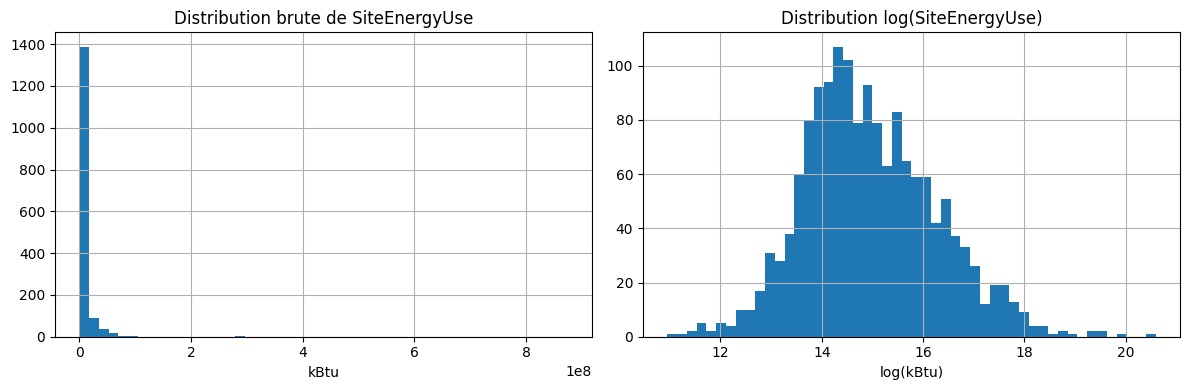

count          1,548
mean       8,860,058
std       31,305,676
min           57,133
25%        1,251,083
50%        2,732,167
75%        7,294,487
max      873,923,712
Name: SiteEnergyUse(kBtu), dtype: str

Skewness : 17.48


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution brute
filtered_21_building_consumption['SiteEnergyUse(kBtu)'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution brute de SiteEnergyUse')
axes[0].set_xlabel('kBtu')

# Distribution log
np.log1p(filtered_21_building_consumption['SiteEnergyUse(kBtu)']).hist(bins=50, ax=axes[1])
axes[1].set_title('Distribution log(SiteEnergyUse)')
axes[1].set_xlabel('log(kBtu)')

plt.tight_layout()
plt.show()

print(filtered_21_building_consumption['SiteEnergyUse(kBtu)'].describe().apply(lambda x: f'{x:,.0f}'))
print(f"\nSkewness : {filtered_21_building_consumption['SiteEnergyUse(kBtu)'].skew():.2f}")

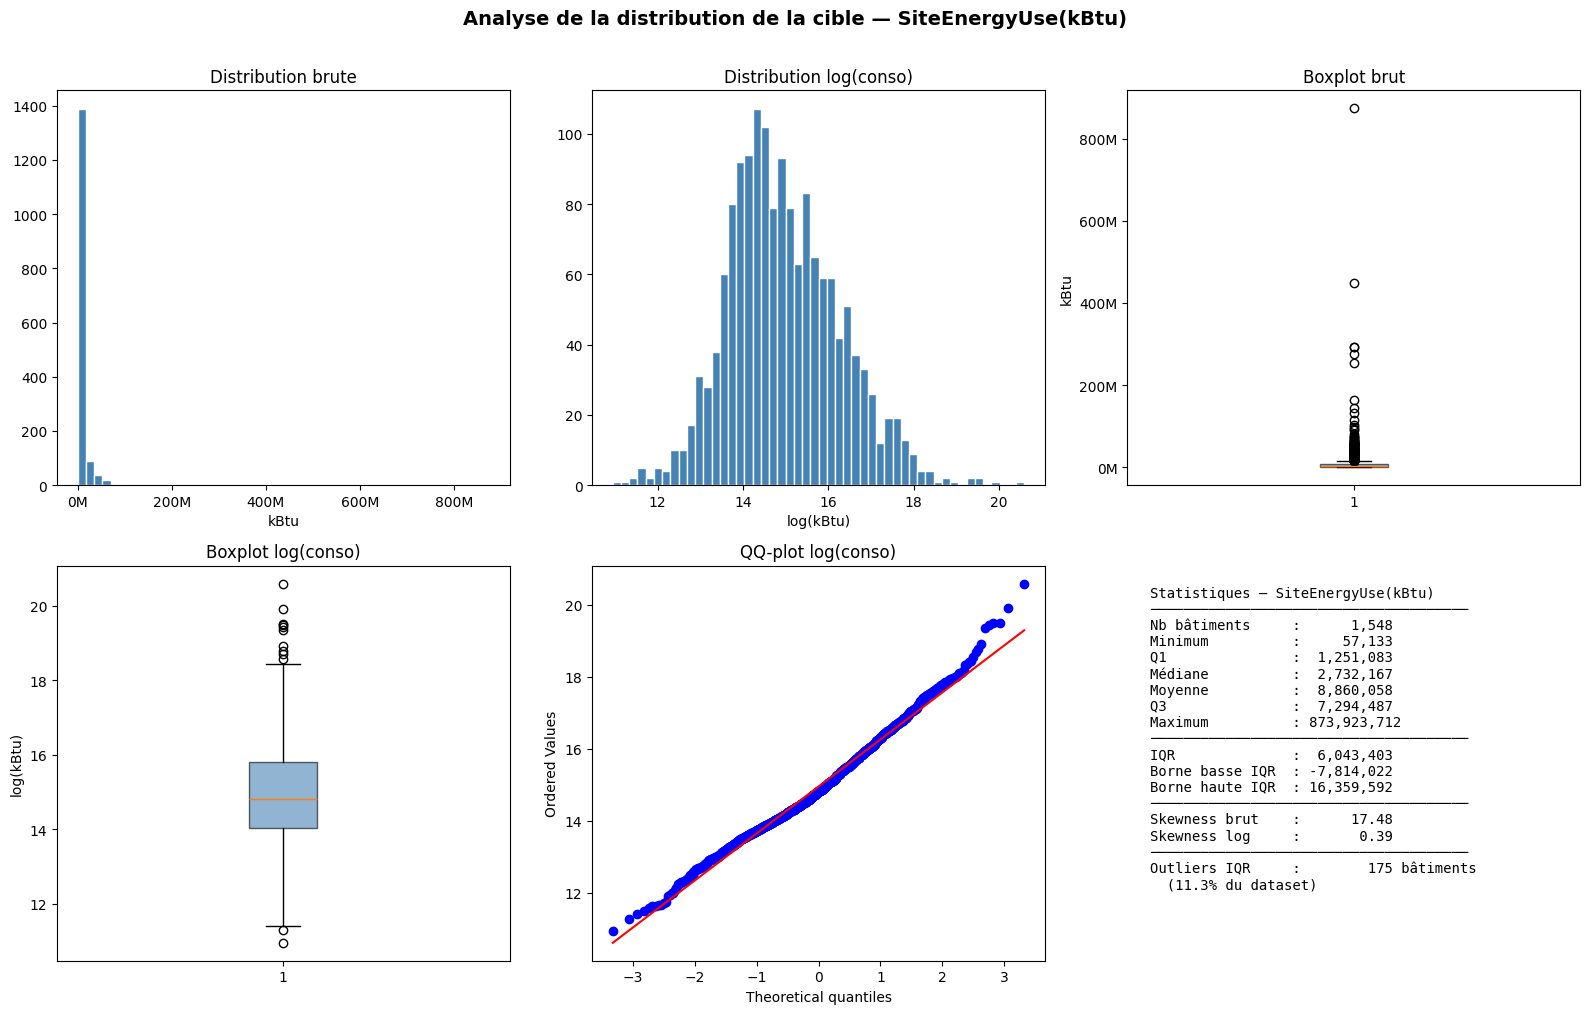

Statistiques — SiteEnergyUse(kBtu)
──────────────────────────────────────
Nb bâtiments     :      1,548
Minimum          :     57,133
Q1               :  1,251,083
Médiane          :  2,732,167
Moyenne          :  8,860,058
Q3               :  7,294,487
Maximum          : 873,923,712
──────────────────────────────────────
IQR              :  6,043,403
Borne basse IQR  : -7,814,022
Borne haute IQR  : 16,359,592
──────────────────────────────────────
Skewness brut    :      17.48
Skewness log     :       0.39
──────────────────────────────────────
Outliers IQR     :        175 bâtiments
  (11.3% du dataset)


In [117]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

target = filtered_21_building_consumption['SiteEnergyUse(kBtu)']
log_target = np.log1p(target)

# ── Graphique 1 : Distribution brute ──────────────────────────
axes[0, 0].hist(target, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution brute')
axes[0, 0].set_xlabel('kBtu')
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# ── Graphique 2 : Distribution log ────────────────────────────
axes[0, 1].hist(log_target, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribution log(conso)')
axes[0, 1].set_xlabel('log(kBtu)')

# ── Graphique 3 : Boxplot brut ────────────────────────────────
axes[0, 2].boxplot(target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0, 2].set_title('Boxplot brut')
axes[0, 2].set_ylabel('kBtu')
axes[0, 2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# ── Graphique 4 : Boxplot log ─────────────────────────────────
axes[1, 0].boxplot(log_target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1, 0].set_title('Boxplot log(conso)')
axes[1, 0].set_ylabel('log(kBtu)')

# ── Graphique 5 : QQ-plot log ─────────────────────────────────
from scipy import stats
stats.probplot(log_target, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot log(conso)')

# ── Graphique 6 : Statistiques textuelles ─────────────────────
axes[1, 2].axis('off')

Q1  = target.quantile(0.25)
Q3  = target.quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR
n_outliers  = ((target < borne_basse) | (target > borne_haute)).sum()

texte = (
    f"Statistiques — SiteEnergyUse(kBtu)\n"
    f"{'─'*38}\n"
    f"Nb bâtiments     : {len(target):>10,}\n"
    f"Minimum          : {target.min():>10,.0f}\n"
    f"Q1               : {Q1:>10,.0f}\n"
    f"Médiane          : {target.median():>10,.0f}\n"
    f"Moyenne          : {target.mean():>10,.0f}\n"
    f"Q3               : {Q3:>10,.0f}\n"
    f"Maximum          : {target.max():>10,.0f}\n"
    f"{'─'*38}\n"
    f"IQR              : {IQR:>10,.0f}\n"
    f"Borne basse IQR  : {borne_basse:>10,.0f}\n"
    f"Borne haute IQR  : {borne_haute:>10,.0f}\n"
    f"{'─'*38}\n"
    f"Skewness brut    : {target.skew():>10.2f}\n"
    f"Skewness log     : {log_target.skew():>10.2f}\n"
    f"{'─'*38}\n"
    f"Outliers IQR     : {n_outliers:>10} bâtiments\n"
    f"  ({n_outliers/len(target)*100:.1f}% du dataset)"
)
axes[1, 2].text(0.05, 0.95, texte, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='top',
                fontfamily='monospace')

plt.suptitle('Analyse de la distribution de la cible — SiteEnergyUse(kBtu)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(texte)

In [118]:
# Regarder les bâtiments au-dessus du p99
p99 = target.quantile(0.99)
outliers = filtered_21_building_consumption[filtered_21_building_consumption['SiteEnergyUse(kBtu)'] > p99][
    ['BuildingAge', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)',
       'Has_Steam', 'Has_Gas', 'Has_Electricity', 'GFA_Commerce_Alimentaire',
       'GFA_Logistique_Stockage', 'GFA_Hotellerie_Logement',
       'GFA_Culture_Loisirs_Culte', 'GFA_Services_Publics_Industrie',
       'GFA_Autre', 'GFA_Sante', 'GFA_Bureau_Finance', 'GFA_Commerce_Retail',
       'GFA_Education']].sort_values('SiteEnergyUse(kBtu)', ascending=False)

#print(outliers.to_string())
outliers.head(20)

,BuildingAge,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),Has_Steam,Has_Gas,Has_Electricity,GFA_Commerce_Alimentaire,GFA_Logistique_Stockage,GFA_Hotellerie_Logement,GFA_Culture_Loisirs_Culte,GFA_Services_Publics_Industrie,GFA_Autre,GFA_Sante,GFA_Bureau_Finance,GFA_Commerce_Retail,GFA_Education
3274,116,111.0,0,0,9320156,873923712.0,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9320156.0
35,24,1.0,3,0,494835,448385312.0,0,1,1,0.0,459748.0,0.0,0.0,0.0,0.0,639931.0,757027.0,0.0,0.0
170,16,9.0,8,0,1158691,293090784.0,1,1,1,0.0,387651.0,0.0,0.0,0.0,0.0,1350182.0,0.0,0.0,0.0
618,22,7.0,14,0,1765970,291614432.0,1,1,1,0.0,441551.0,0.0,0.0,0.0,0.0,1639334.0,0.0,0.0,0.0
558,35,1.0,33,0,429405,274682208.0,0,1,1,0.0,0.0,0.0,0.0,218997.0,0.0,0.0,210409.0,0.0,0.0
124,63,6.0,10,0,879000,253832464.0,0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,879000.0,0.0,0.0,0.0
3264,96,1.0,8,0,374466,163945984.0,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1010135.0,0.0,0.0,0.0
167,26,6.0,5,0,597519,143423024.0,0,1,1,0.0,48607.0,0.0,0.0,0.0,0.0,601615.0,0.0,0.0,0.0
340,19,1.0,5,0,535947,131373880.0,0,1,1,0.0,103983.0,0.0,0.0,0.0,535947.0,0.0,0.0,0.0,0.0
1494,77,1.0,2,0,2200000,114648520.0,0,1,1,0.0,318960.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1719643.0


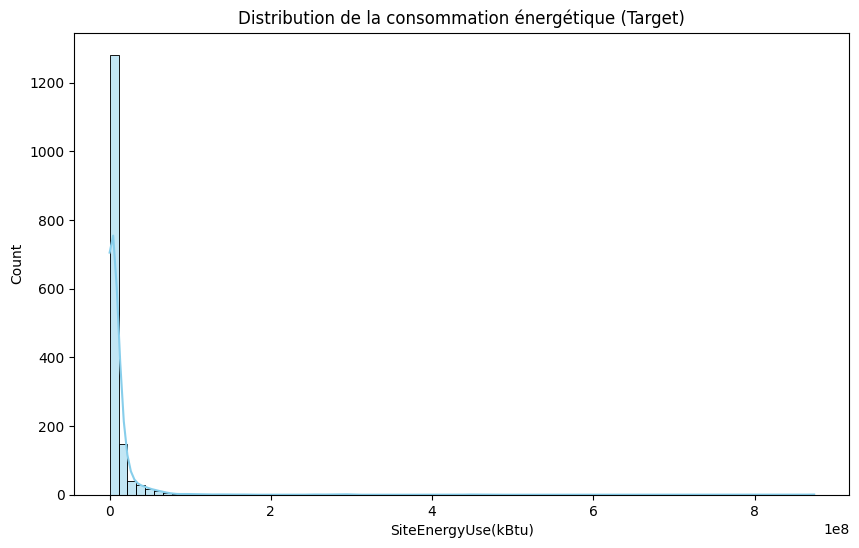

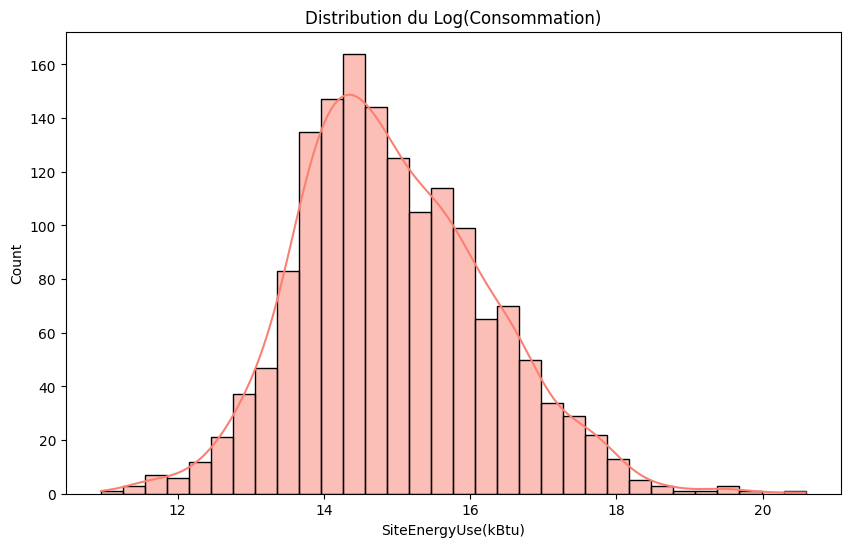

In [119]:

# Visualisation de la distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_21_building_consumption['SiteEnergyUse(kBtu)'], kde=True, color='skyblue')
plt.title("Distribution de la consommation énergétique (Target)")
plt.show()

# Test de la transformation logarithmique (très souvent recommandée)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(filtered_21_building_consumption['SiteEnergyUse(kBtu)']), kde=True, color='salmon')
plt.title("Distribution du Log(Consommation)")
plt.show()

3) Matrice de corrélation et variables redondantes
On fait une matrice de corrélation pour visualiser les variables qui seraient potentiellement redondantes.

Avant de supprimer PropertyGFATotal, on avait une très forte corrélation de celle-ci avec les variables PropertyGFABuilding(s) et PropertyGFAParking (mais surtout PropertyGFABuilding(s)).
Désormais, on voit que mis à part la corrélation entre NumberofBuildings et GFA_Education (Surface associé à l'éducation), les variables ne sont jamais corrélés à plus de 83% (ce qui n'st pas un motif de suppression).

En effet, si deux variables sont corrélées à 0.99, elles apportent la même information. En garder une seule simplifie le modèle sans perdre de performance. En général, on peut décréter que deux variables sont trop corrélés si leur coefficient de corrélation est supérieur à 95%. Dans ce cas, elles fournissent la même information et on peut en supprimer une des deux.

Par ailleurs, le lien entre NumberofBuildings et GFA_Education n'étant pas évident, on ne supprime pas davantage de variables.

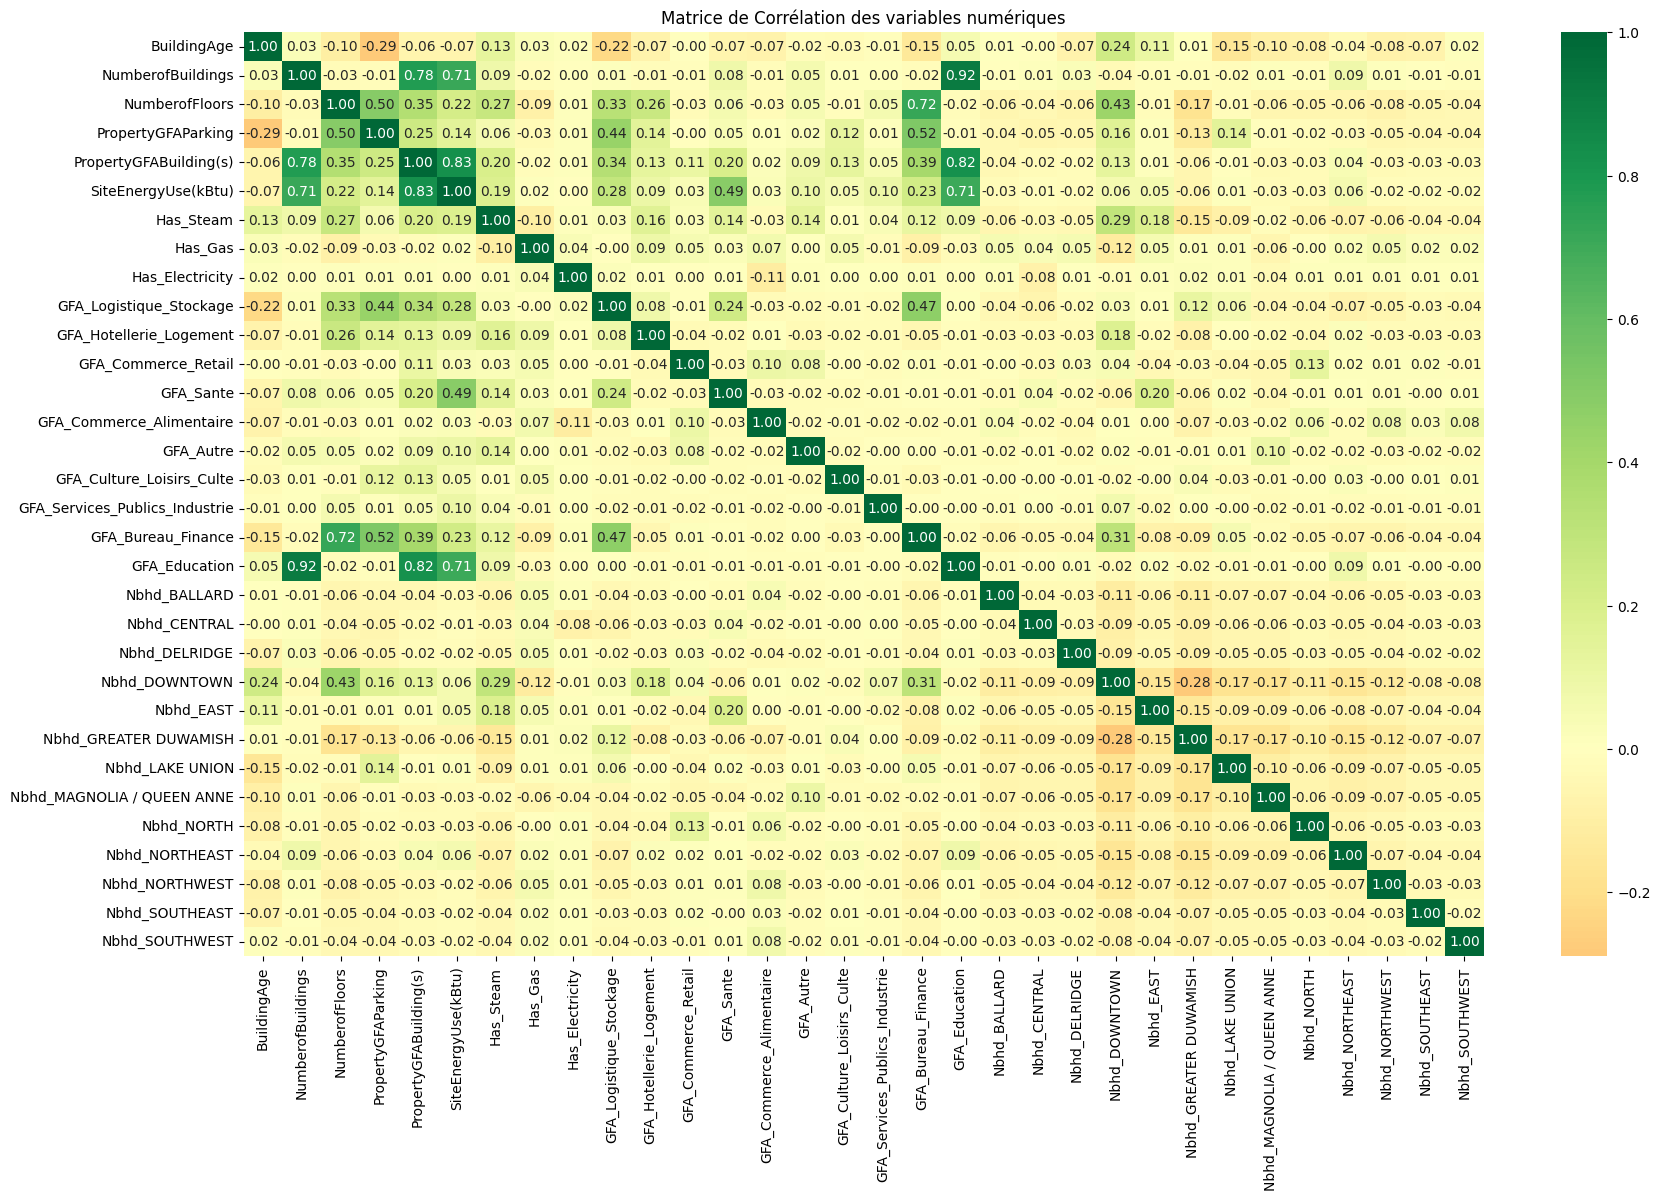

In [120]:
# Calcul de la matrice de corrélation
corr = filtered_21_building_consumption.corr()

# Affichage
plt.figure(figsize=(20,12))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matrice de Corrélation des variables numériques')
plt.show()

4) Analyse des liens entre les features et la target

a) lien entre PropertyGFABuilding(s) (Surface du batiment - hors parking) et SiteEnergyUse(kBtu) (Consommation d'energie - Cible) - Scatteplot

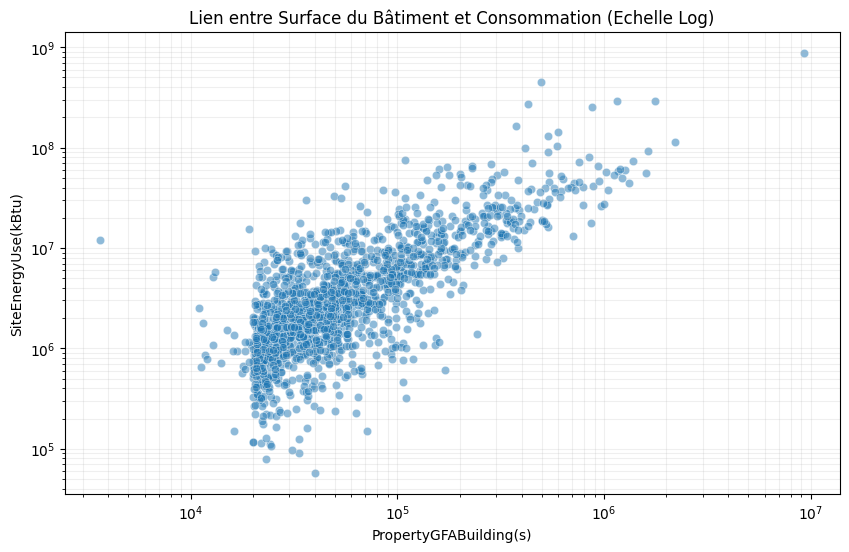

In [121]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_21_building_consumption, x='PropertyGFABuilding(s)', y='SiteEnergyUse(kBtu)', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title("Lien entre Surface du Bâtiment et Consommation (Echelle Log)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

b) Distribution de la consommation d'energie (SiteEnergyUse(kBtu) en fonction du quartier (Neighborhood) - AVANT Encodage

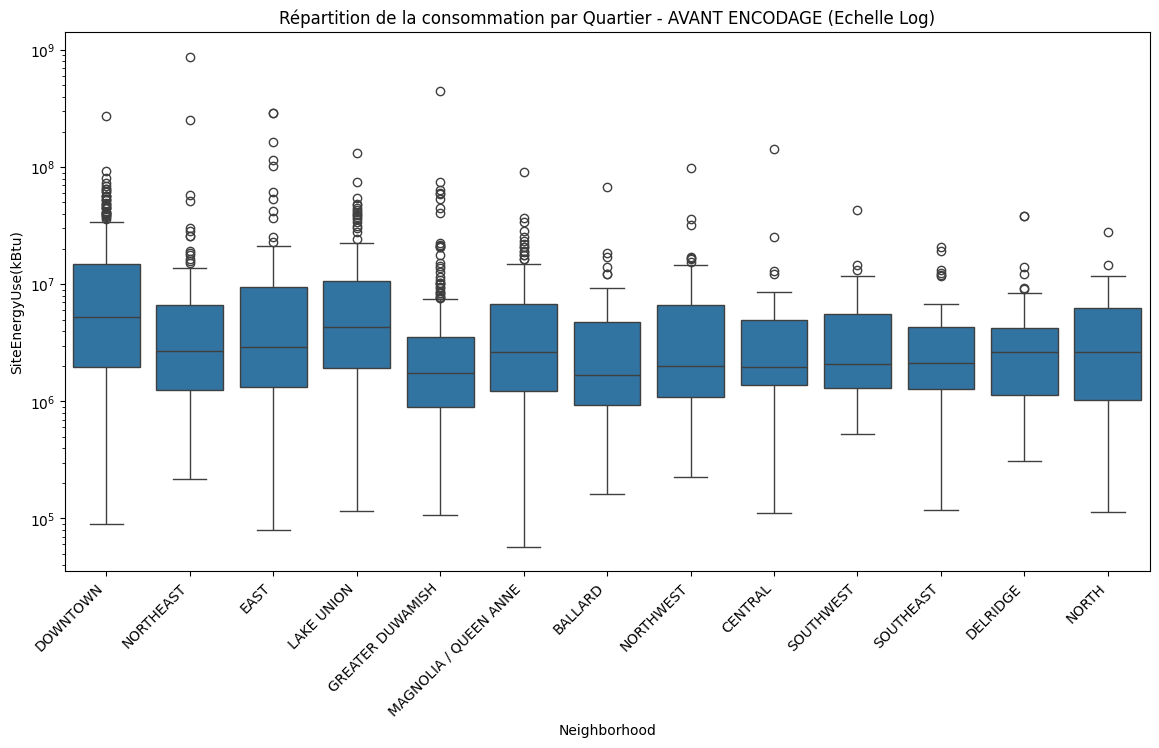

In [122]:
# On génère une visualisation du lien entre Neighborhood et SiteEnergyUse(kBtu) avant encodage
plt.figure(figsize=(14, 7))
sns.boxplot(x='Neighborhood', y='SiteEnergyUse(kBtu)', data=filtered_17_building_consumption)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title("Répartition de la consommation par Quartier - AVANT ENCODAGE (Echelle Log)")
plt.show()

c) lien entre toutes les variables numériques et SiteEnergyUse(kBtu) (Consommation d'energie - Cible) - Barplot

/tmp/ipykernel_11874/2338443805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


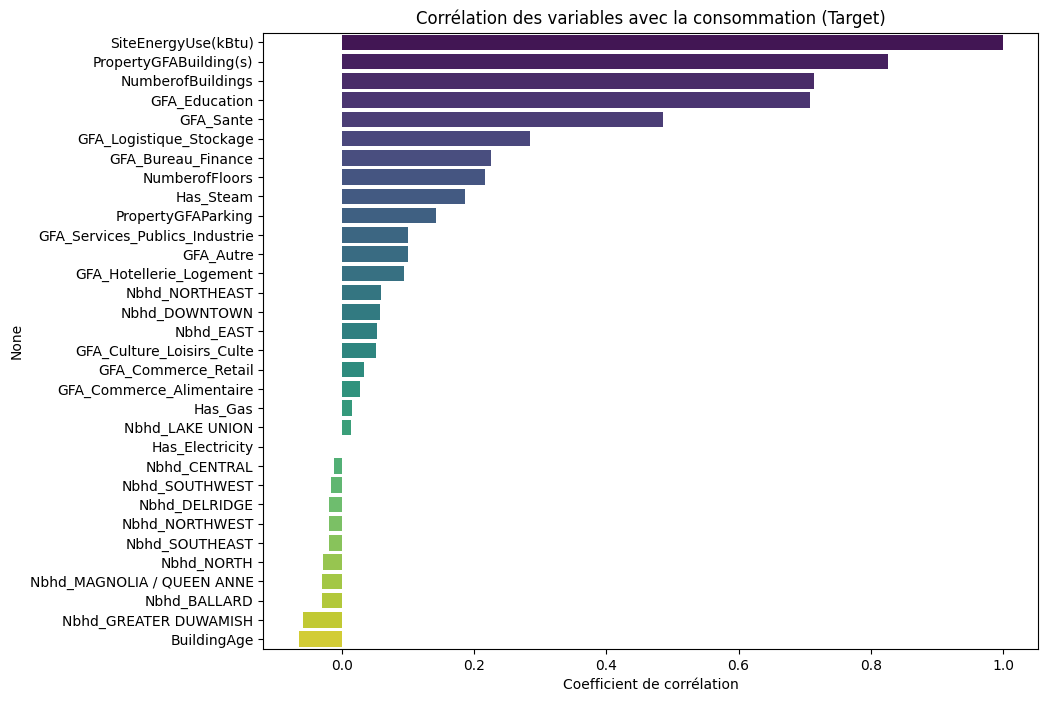

In [123]:
# On calcule la corrélation de toutes les variables avec la cible uniquement
correlations = filtered_21_building_consumption.corr()['SiteEnergyUse(kBtu)'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title("Corrélation des variables avec la consommation (Target)")
plt.xlabel("Coefficient de corrélation")
plt.show()

d) lien entre l'age du Batiment et SiteEnergyUse(kBtu) (Consommation d'energie - Cible) - regplot

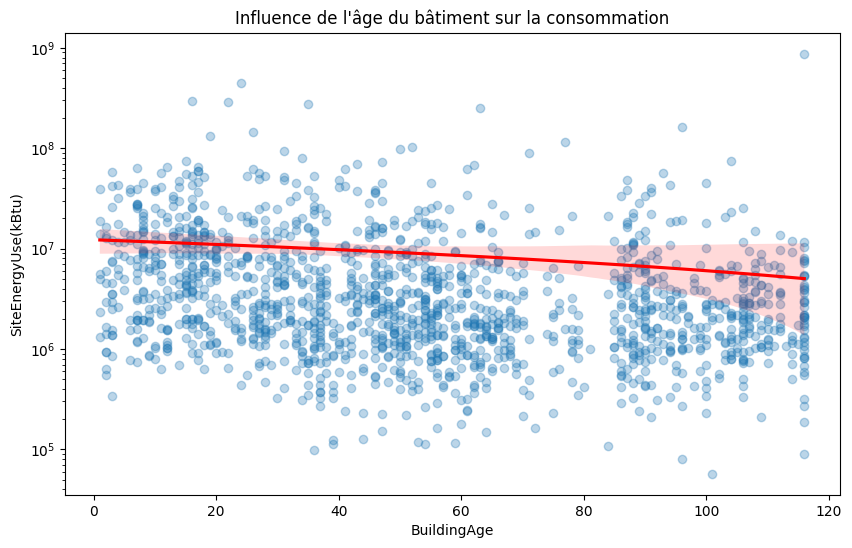

In [124]:
plt.figure(figsize=(10, 6))
sns.regplot(data=filtered_21_building_consumption, x='BuildingAge', y='SiteEnergyUse(kBtu)', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.yscale('log')
plt.title("Influence de l'âge du bâtiment sur la consommation")
plt.show()

d) lien entre différentes variables entre elles ('BuildingAge', 'PropertyGFABuilding(s)', 'NumberofFloors', 'SiteEnergyUse(kBtu)'), dont la consommation d'energie (cible)

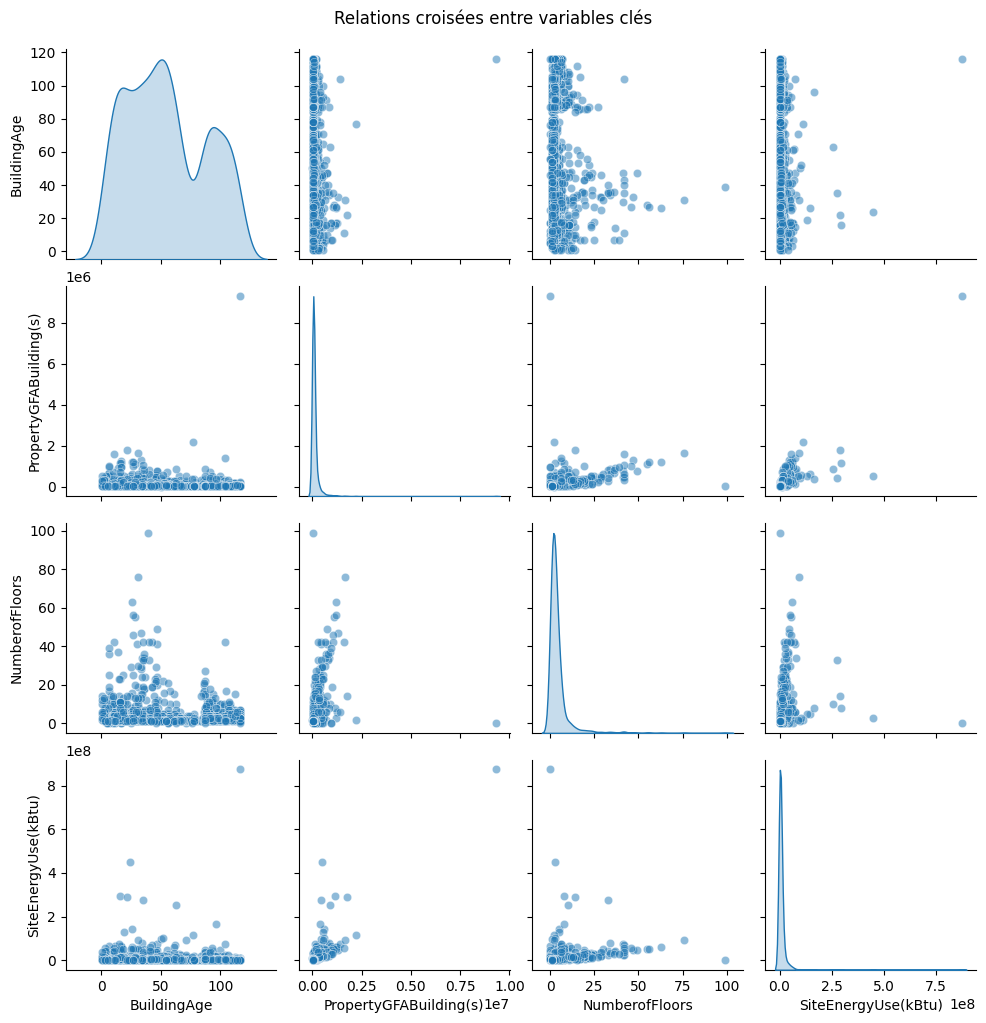

In [125]:
# Sélection de quelques variables clés pour ne pas surcharger le graphique
clés = ['BuildingAge', 'PropertyGFABuilding(s)', 'NumberofFloors', 'SiteEnergyUse(kBtu)']
sns.pairplot(filtered_21_building_consumption[clés], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Relations croisées entre variables clés", y=1.02)
plt.show()

5) Encodage des features catégorielles

Toutes les features catégorielles ont déjà été encodées (la dernière étant 'Neighborhood'), il ne reste plus que des variables 'numériques'.
A voir si cela correspond à la tâche 'Normaliser les features si cela est nécessaire.' dans le compte-rendu de session de ler avril (à confirmer avec Ugo).

Il serait intéressant de reformuler les catégories des 'usages' en fonction des consommations d'energie et non en fonction de ce que l'on pense être comme des profils similaires.
En attendant, ci-joint un code python permettant de visualiser les consommations des batiments en fonction de leur premier "premier" usage (c'est à dire l'usage avec la plus grande surface).


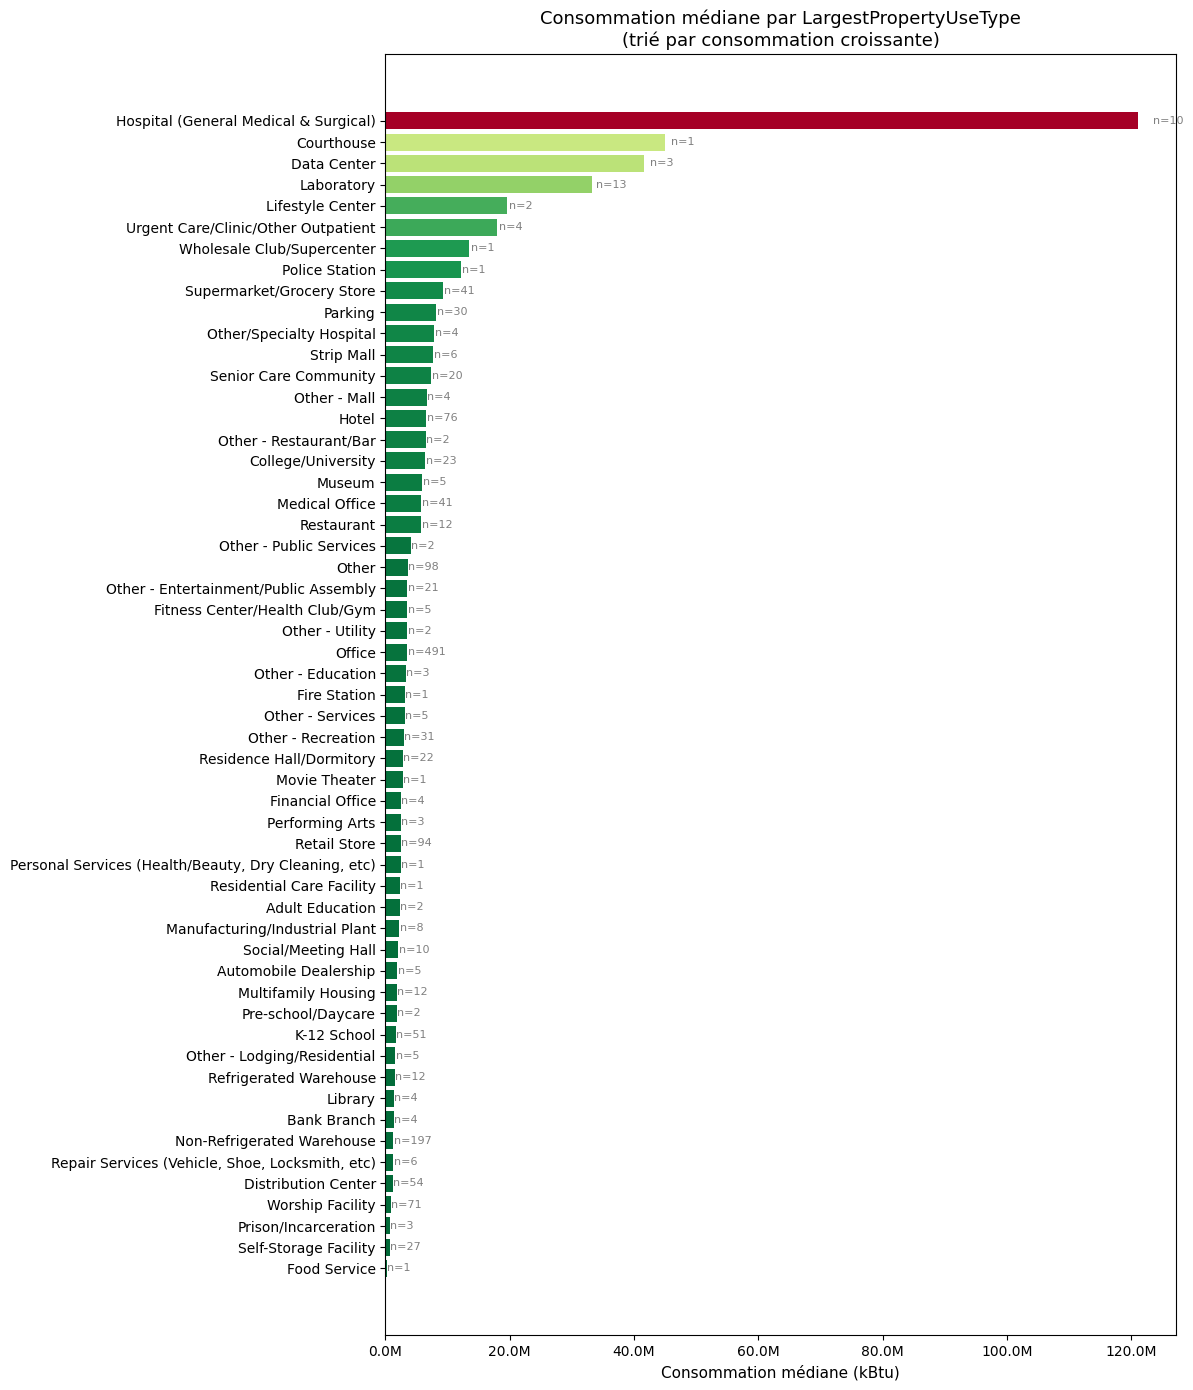

/tmp/ipykernel_11874/147088336.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


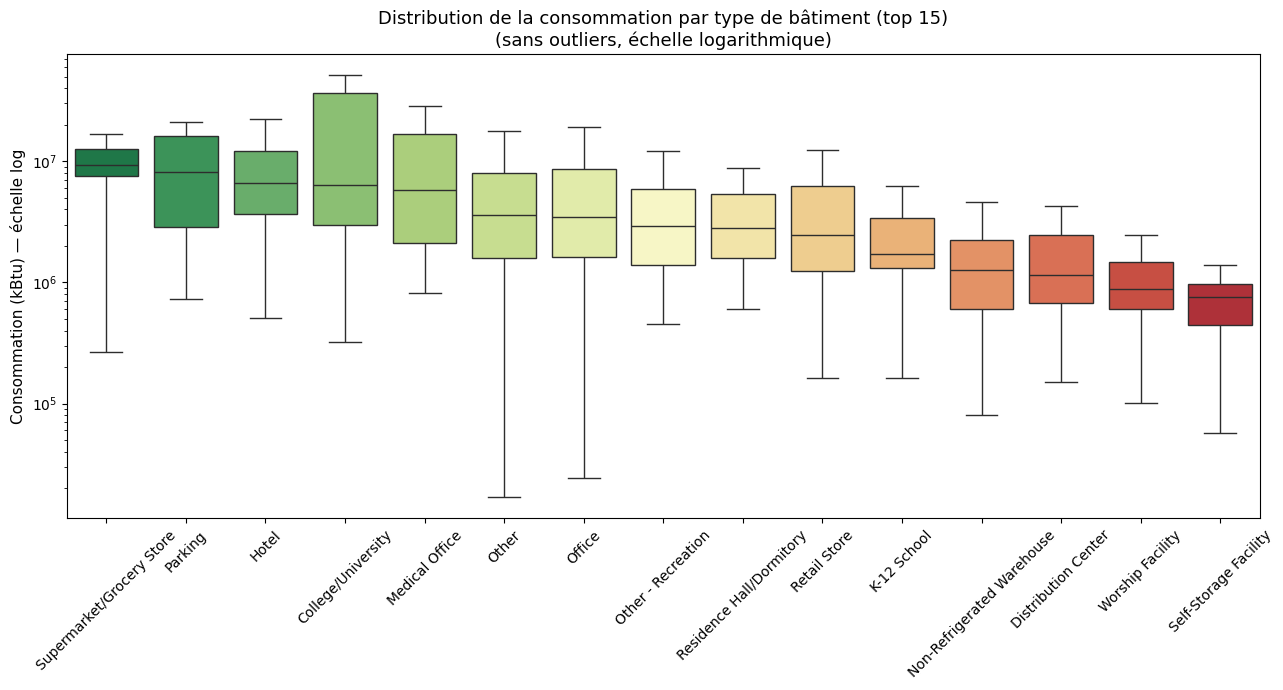

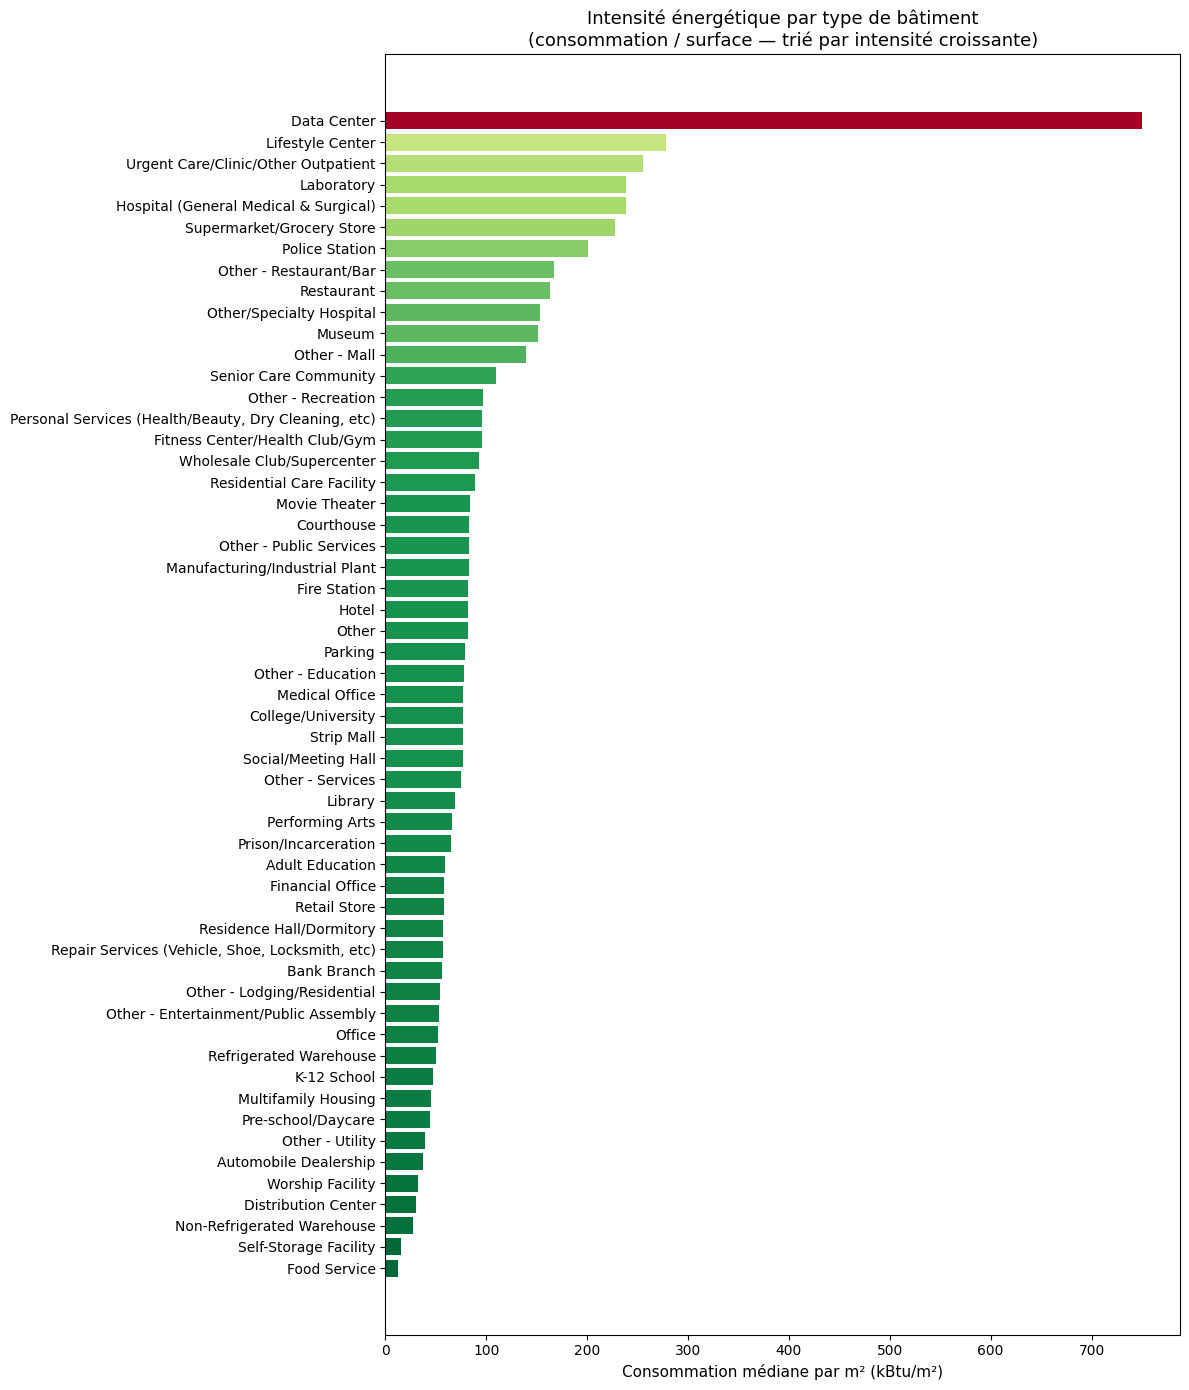

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Repartir du dataset avant mapping pour avoir les modalités originales
#df_raw = filtered_15_building_consumption.copy()
df_raw = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

# Appliquer les mêmes filtres qu'avant
types_non_residentiels = ['NonResidential', 'Nonresidential COS', 'NonResidential WA', 'SPS-District K-12', 'Campus']
df_raw = df_raw[df_raw['BuildingType'].isin(types_non_residentiels)].copy()
df_raw = df_raw[df_raw['SiteEnergyUse(kBtu)'].notna() & (df_raw['SiteEnergyUse(kBtu)'] > 0)]
df_raw = df_raw[df_raw['DefaultData'] == False].copy()

# ============================================================
# GRAPHIQUE 1 — Consommation médiane par LargestPropertyUseType
# Trié par consommation médiane pour visualiser les groupes naturels
# ============================================================

medians = (
    df_raw.groupby('LargestPropertyUseType')['SiteEnergyUse(kBtu)']
    .agg(['median', 'count'])
    .reset_index()
    .sort_values('median', ascending=True)
)

# Couleur selon la consommation (dégradé)
norm = plt.Normalize(medians['median'].min(), medians['median'].max())
colors = plt.cm.RdYlGn_r(norm(medians['median']))

fig, ax = plt.subplots(figsize=(12, 14))
bars = ax.barh(medians['LargestPropertyUseType'], medians['median'], color=colors)

# Annoter avec le nombre de bâtiments
for i, (_, row) in enumerate(medians.iterrows()):
    ax.text(row['median'] * 1.02, i, f"n={int(row['count'])}",
            va='center', fontsize=8, color='gray')

ax.set_xlabel('Consommation médiane (kBtu)', fontsize=11)
ax.set_title('Consommation médiane par LargestPropertyUseType\n(trié par consommation croissante)', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# ============================================================
# GRAPHIQUE 2 — Boxplot pour voir la dispersion par type
# (on garde les 15 types les plus représentés pour la lisibilité)
# ============================================================

top15 = (
    df_raw['LargestPropertyUseType']
    .value_counts()
    .head(15)
    .index
)

df_top15 = df_raw[df_raw['LargestPropertyUseType'].isin(top15)].copy()

# Ordre par médiane
ordre = (
    df_top15.groupby('LargestPropertyUseType')['SiteEnergyUse(kBtu)']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=df_top15,
    x='LargestPropertyUseType',
    y='SiteEnergyUse(kBtu)',
    order=ordre,
    showfliers=False,   # on masque les outliers pour la lisibilité
    palette='RdYlGn_r',
    ax=ax
)
ax.set_yscale('log')   # échelle log car forte asymétrie
ax.set_xlabel('')
ax.set_ylabel('Consommation (kBtu) — échelle log', fontsize=11)
ax.set_title('Distribution de la consommation par type de bâtiment (top 15)\n(sans outliers, échelle logarithmique)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# GRAPHIQUE 3 — Consommation médiane par unité de surface (kBtu/m²)
# Pour comparer les types indépendamment de leur taille
# ============================================================

df_raw['conso_par_m2'] = df_raw['SiteEnergyUse(kBtu)'] / df_raw['PropertyGFABuilding(s)'].replace(0, np.nan)

medians_m2 = (
    df_raw.groupby('LargestPropertyUseType')['conso_par_m2']
    .median()
    .dropna()
    .sort_values(ascending=True)
    .reset_index()
)

norm2 = plt.Normalize(medians_m2['conso_par_m2'].min(), medians_m2['conso_par_m2'].max())
colors2 = plt.cm.RdYlGn_r(norm2(medians_m2['conso_par_m2']))

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(medians_m2['LargestPropertyUseType'], medians_m2['conso_par_m2'], color=colors2)
ax.set_xlabel('Consommation médiane par m² (kBtu/m²)', fontsize=11)
ax.set_title('Intensité énergétique par type de bâtiment\n(consommation / surface — trié par intensité croissante)', fontsize=13)
plt.tight_layout()
plt.show()

6) Séparation du jeu de données (Feaures - X / Target - Y)

In [133]:
print(filtered_21_building_consumption.columns)

Index(['BuildingAge', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)',
       'Has_Steam', 'Has_Gas', 'Has_Electricity', 'GFA_Logistique_Stockage',
       'GFA_Hotellerie_Logement', 'GFA_Commerce_Retail', 'GFA_Sante',
       'GFA_Commerce_Alimentaire', 'GFA_Autre', 'GFA_Culture_Loisirs_Culte',
       'GFA_Services_Publics_Industrie', 'GFA_Bureau_Finance', 'GFA_Education',
       'Nbhd_BALLARD', 'Nbhd_CENTRAL', 'Nbhd_DELRIDGE', 'Nbhd_DOWNTOWN',
       'Nbhd_EAST', 'Nbhd_GREATER DUWAMISH', 'Nbhd_LAKE UNION',
       'Nbhd_MAGNOLIA / QUEEN ANNE', 'Nbhd_NORTH', 'Nbhd_NORTHEAST',
       'Nbhd_NORTHWEST', 'Nbhd_SOUTHEAST', 'Nbhd_SOUTHWEST'],
      dtype='str')


In [127]:
# 1. On définit la cible (y)
y = filtered_21_building_consumption['SiteEnergyUse(kBtu)']

# 2. On définit les variables explicatives (X)
# On enlève la cible et les colonnes de test qu'on aurait pu laisser
X = filtered_21_building_consumption.drop(columns=['SiteEnergyUse(kBtu)'])
#cols = ['BuildingAge', 'NumberofBuildings', 'NumberofFloors','PropertyGFAParking', 'PropertyGFABuilding(s)','Has_Steam', 'Has_Gas', 'Has_Electricity','GFA_Commerce_Retail', 'GFA_Education', 'GFA_Autre','GFA_Hotellerie_Logement', 'GFA_Bureau_Finance','GFA_Commerce_Alimentaire', 'GFA_Logistique_Stockage','GFA_Services_Publics_Industrie', 'GFA_Sante']
#X = filtered_21_building_consumption[cols]

# 3. On vérifie les types pour être sûr que tout est numérique (int ou float)
print(X.dtypes.value_counts())

int64      20
float64    11
Name: count, dtype: int64


In [129]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [130]:
import sklearn
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [144]:
reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Autre méthode, celle du cours

In [145]:
print(reg.score(X, y))

0.8780197522385305


In [134]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [136]:
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [146]:
print(reg.score(X_train, y_train))

0.7112681705212507


In [147]:
y_pred_test = reg.predict(X_test)

In [138]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
print(f"RMSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test)}")

RMSE: 620166524007185.5
MAPE: 1.5598952644059607


In [141]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, r2_score

# On définit une fonction pour évaluer n'importe quel modèle
def evaluate_model(model, name, X, y):
    # 1. Validation croisée pour vérifier la robustesse
    # On demande le R2 et la MAE (négative car sklearn minimise l'erreur)
    cv_results = cross_validate(model, X, y, cv=5, 
                                scoring=['r2', 'neg_mean_absolute_error'])
    
    r2_cv = cv_results['test_r2'].mean()
    mae_cv = -cv_results['test_neg_mean_absolute_error'].mean()
    
    print(f"--- Modèle : {name} ---")
    print(f"R² moyen (Cross-Val) : {r2_cv:.3f}")
    print(f"MAE moyenne (Cross-Val) : {mae_cv:.2f}")
    
    return {'Modèle': name, 'R2': r2_cv, 'MAE': mae_cv}

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor # Si tu l'as installé

# On stocke les résultats pour faire un tableau final
results = []

# 1. Régression Linéaire (Baseline)
lr = LinearRegression()
results.append(evaluate_model(lr, "Régression Linéaire", X, y))

# 1. a. Régression Linéaire (Baseline)
lr = LinearRegression()
results.append(evaluate_model(lr, "Régression Linéaire X et y train", X_train, y_train))

# 1. b. Régression Linéaire (Baseline)
lr = LinearRegression()
results.append(evaluate_model(lr, "Régression Linéaire X et y test", X_test, y_test))

# 2. Random Forest (Modèle non-linéaire robuste)
rf = RandomForestRegressor(random_state=42)
results.append(evaluate_model(rf, "Random Forest", X, y))

# 3. XGBoost (Modèle très performant)
xgb = XGBRegressor(random_state=42)
results.append(evaluate_model(xgb, "XGBoost", X, y))

# Tableau récapitulatif
df_results = pd.DataFrame(results)
display(df_results)

--- Modèle : Régression Linéaire ---
R² moyen (Cross-Val) : 0.564
MAE moyenne (Cross-Val) : 5025860.56
--- Modèle : Régression Linéaire X et y train ---
R² moyen (Cross-Val) : 0.660
MAE moyenne (Cross-Val) : 4067863.85
--- Modèle : Régression Linéaire X et y test ---
R² moyen (Cross-Val) : 0.354
MAE moyenne (Cross-Val) : 8335517.88
--- Modèle : Random Forest ---
R² moyen (Cross-Val) : 0.032
MAE moyenne (Cross-Val) : 4948172.34
--- Modèle : XGBoost ---
R² moyen (Cross-Val) : -0.202
MAE moyenne (Cross-Val) : 5201487.36


,Modèle,R2,MAE
0,Régression Linéaire,0.563845,5.025861e+06
1,Régression Linéaire X et y train,0.660252,4.067864e+06
2,Régression Linéaire X et y test,0.353707,8.335518e+06
3,Random Forest,0.032449,4.948172e+06
4,XGBoost,-0.202401,5.201487e+06


In [116]:
# 1. On transforme la cible en log
y_train_log = np.log1p(y)

# 2. On relance la comparaison sur y_train_log
# Note : Tes MAE seront alors très petites (autour de 0.4 - 0.7), c'est normal !
results_log = []

results_log.append(evaluate_model(lr, "Régression Linéaire (Log)", X, y_train_log))
results_log.append(evaluate_model(rf, "Random Forest (Log)", X, y_train_log))
results_log.append(evaluate_model(xgb, "XGBoost (Log)", X, y_train_log))

display(pd.DataFrame(results_log))

--- Modèle : Régression Linéaire (Log) ---
R² moyen (Cross-Val) : -0.155
MAE moyenne (Cross-Val) : 0.81
--- Modèle : Random Forest (Log) ---
R² moyen (Cross-Val) : 0.594
MAE moyenne (Cross-Val) : 0.53
--- Modèle : XGBoost (Log) ---
R² moyen (Cross-Val) : 0.555
MAE moyenne (Cross-Val) : 0.56


,Modèle,R2,MAE
0,Régression Linéaire (Log),-0.155232,0.808199
1,Random Forest (Log),0.593682,0.531170
2,XGBoost (Log),0.555408,0.558312


In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE